In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# read in the CSV
#path = '/Volumes/disk1/Central Valley Fog/CV_rows.csv'
path = 'E:/Central Valley Fog/CV_rows_cleaned.csv'

CV_rows = pd.read_csv(path, low_memory=False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [4]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 11)


In [5]:
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (212676, 11)


In [6]:
CV_densefog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 0.403)
]

print("CV_densefog_rows:", CV_densefog_rows.shape)

CV_densefog_rows: (144572, 11)


In [7]:
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

19 stations with data back to at least 1970
['USM00074917', 'USM00074918', 'USW00023106', 'USW00023110', 'USW00023155', 'USW00023167', 'USW00023202', 'USW00023203', 'USW00023206', 'USW00023208', 'USW00023232', 'USW00023237', 'USW00023238', 'USW00023242', 'USW00024216', 'USW00024257', 'USW00053125', 'USW00093193', 'USW00093216']


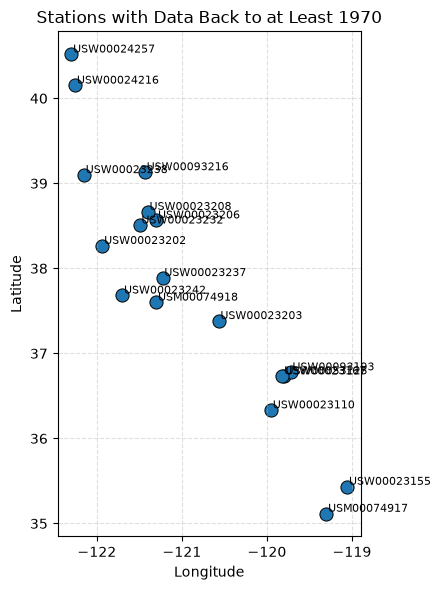

In [18]:
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
plt.scatter(
    station_locations['LONGITUDE'],
    station_locations['LATITUDE'],
    s=90,
    color='tab:blue',
    edgecolor='black',
    linewidth=0.7
)

for _, row in station_locations.iterrows():
    plt.text(
        row['LONGITUDE'] + 0.02,
        row['LATITUDE'] + 0.02,
        row['STATION'],
        fontsize=8
    )

plt.title('Stations with Data Back to at Least 1970')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [8]:
fog_days_pre1970_stations = (
    CV_fog_rows[CV_fog_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_days')
    .sort_values(['STATION', 'year'])
)

print(fog_days_pre1970_stations)

         STATION  year  fog_days
0    USM00074917  1941         3
1    USM00074917  1942        15
2    USM00074917  1943         7
3    USM00074917  1944        12
4    USM00074917  1945         7
..           ...   ...       ...
929  USW00093216  2022        17
930  USW00093216  2023        16
931  USW00093216  2024        16
932  USW00093216  2025        31
933  USW00093216  2026        14

[934 rows x 3 columns]


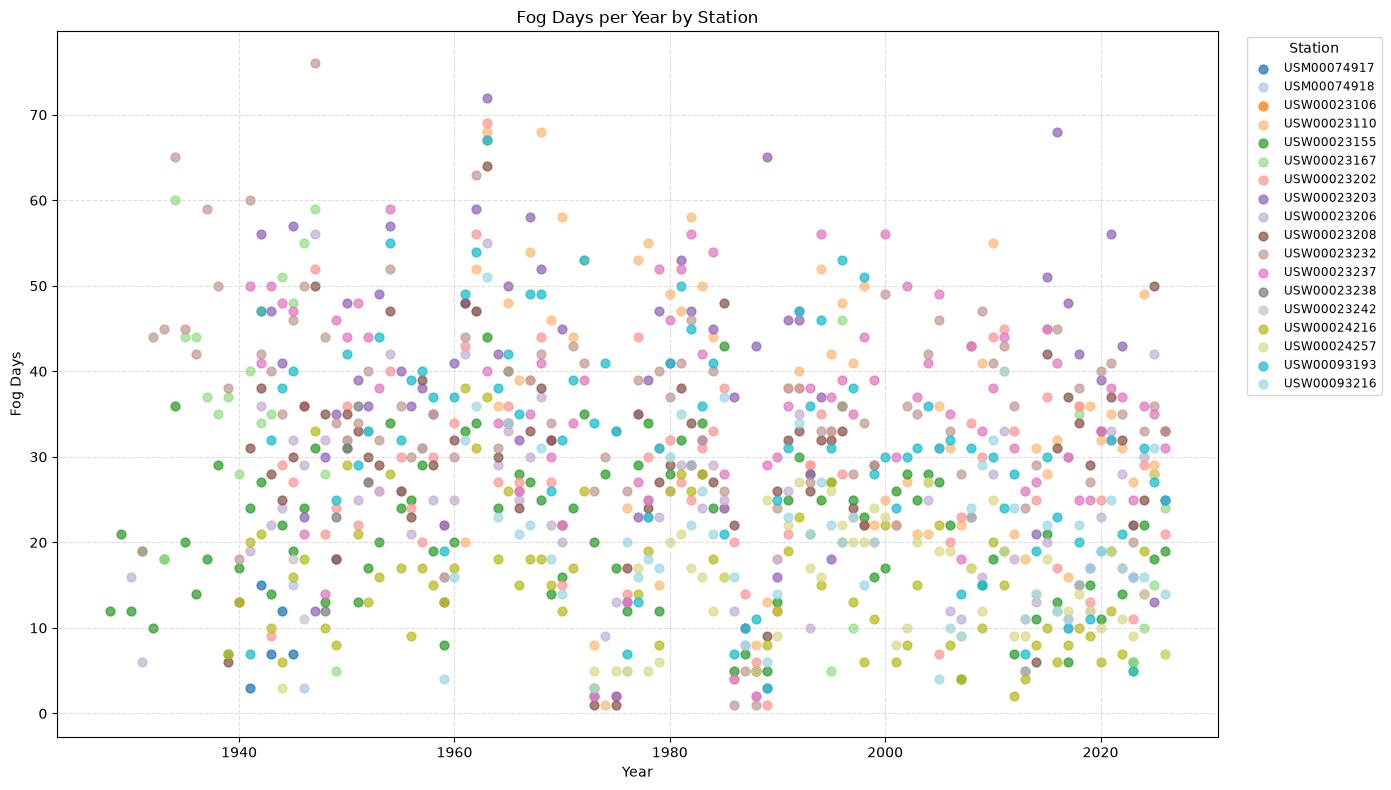

In [9]:
plt.figure(figsize=(14, 8))

stations = fog_days_pre1970_stations['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_pre1970_stations[fog_days_pre1970_stations['STATION'] == station]
    plt.scatter(
        station_df['year'],
        station_df['fog_days'],
        color=colors[i],
        label=station,
        s=40,
        alpha=0.75
    )

plt.title('Fog Days per Year by Station')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

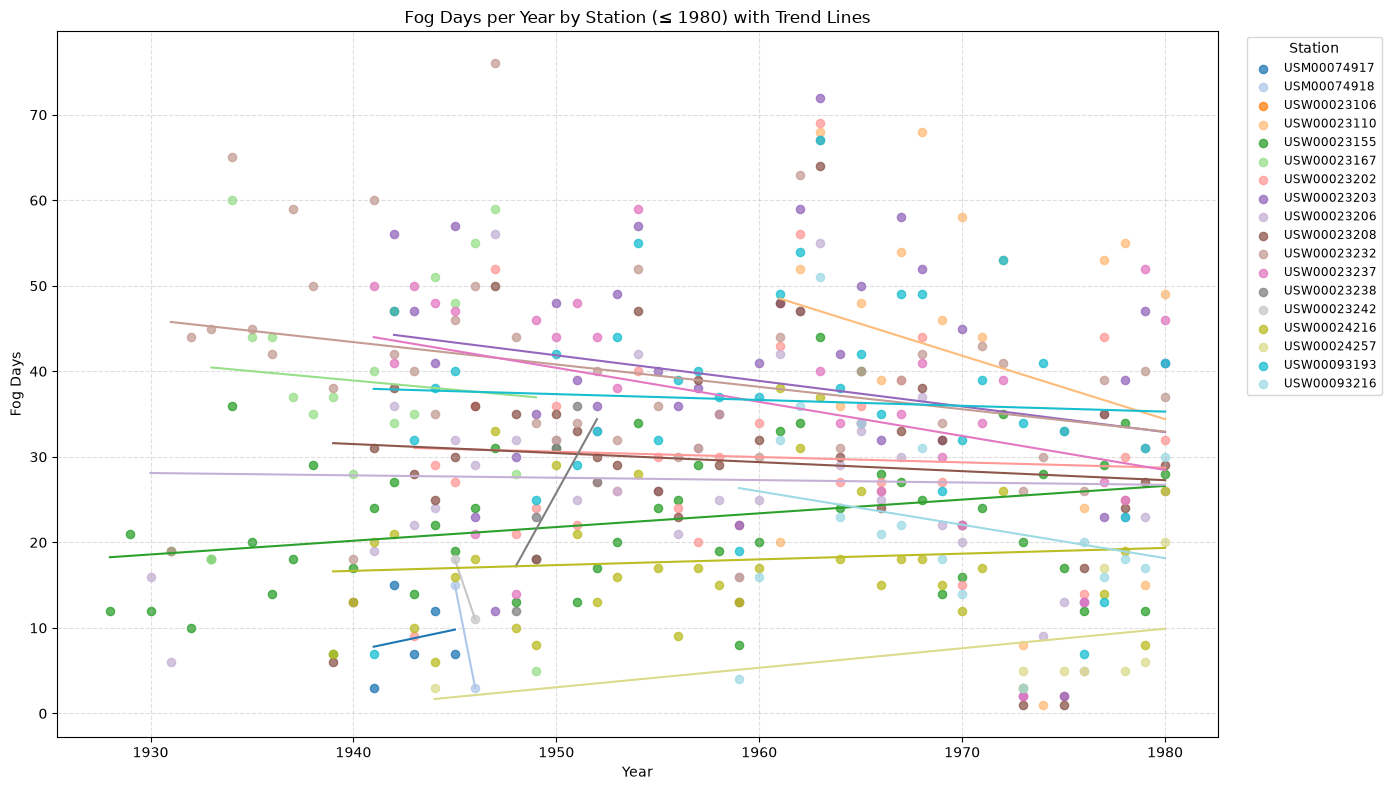

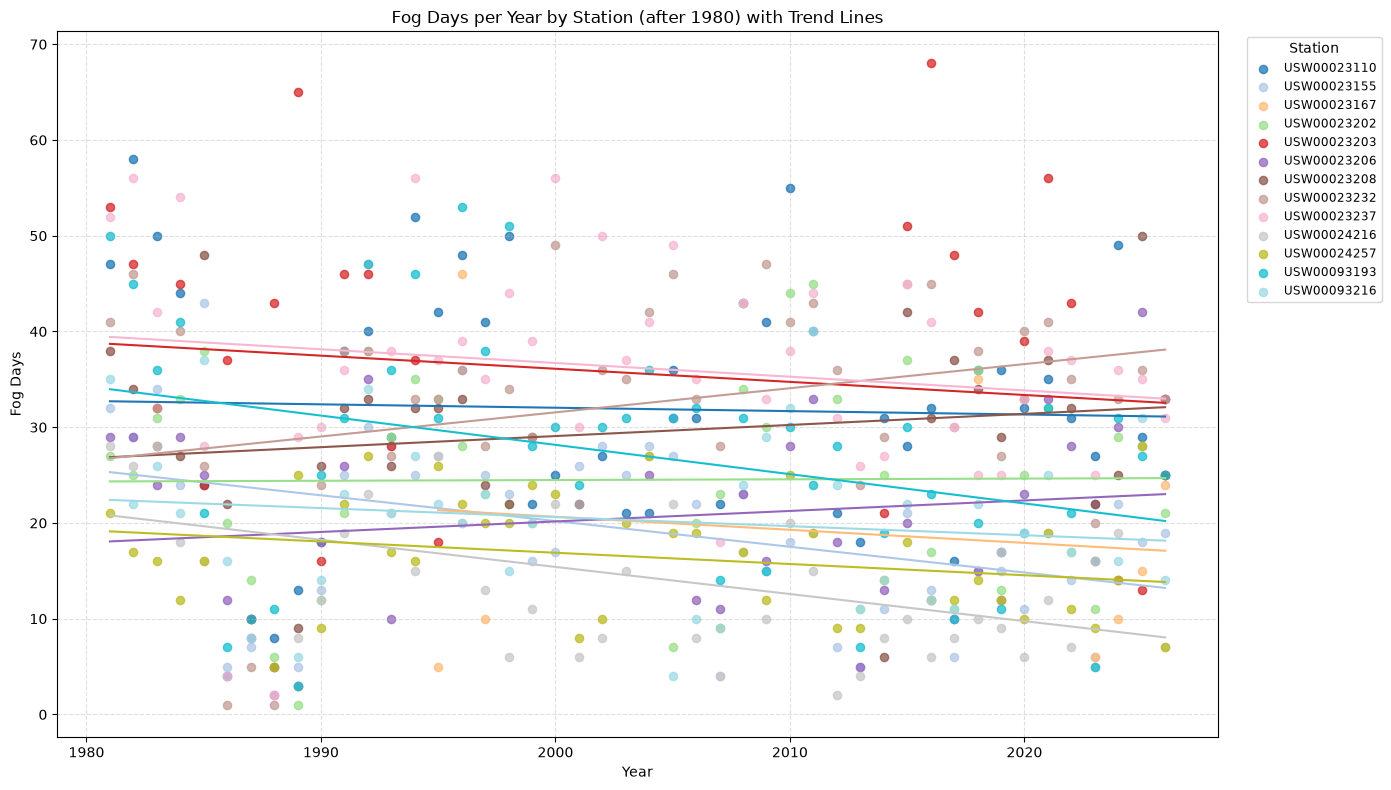

In [10]:
fog_days_pre1980 = fog_days_pre1970_stations[fog_days_pre1970_stations['year'] <= 1980]
fog_days_post1980 = fog_days_pre1970_stations[fog_days_pre1970_stations['year'] > 1980]

plt.figure(figsize=(14, 8))
stations_pre = fog_days_pre1980['STATION'].unique()
colors_pre = plt.cm.tab20(np.linspace(0, 1, len(stations_pre)))

for i, station in enumerate(stations_pre):
    station_df = fog_days_pre1980[fog_days_pre1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors_pre[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors_pre[i], linewidth=1.5)

plt.title('Fog Days per Year by Station (≤ 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

plt.figure(figsize=(14, 8))
stations_post = fog_days_post1980['STATION'].unique()
colors_post = plt.cm.tab20(np.linspace(0, 1, len(stations_post)))

for i, station in enumerate(stations_post):
    station_df = fog_days_post1980[fog_days_post1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors_post[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors_post[i], linewidth=1.5)

plt.title('Fog Days per Year by Station (after 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

In [11]:
from scipy import stats

post_fit_stats = []

for station, station_df in fog_days_post1980.groupby('STATION'):
    station_df = station_df.sort_values('year')
    x = station_df['year'].astype(float)
    y = station_df['fog_days'].astype(float)

    if len(station_df) >= 2:
        res = stats.linregress(x, y)
        post_fit_stats.append({
            'STATION': station,
            'slope': res.slope,
            'intercept': res.intercept,
            'r_squared': res.rvalue ** 2,
            'p_value': res.pvalue,
            'stderr': res.stderr,
            'n_obs': len(station_df),
        })

post_fit_stats_df = pd.DataFrame(post_fit_stats).sort_values('r_squared', ascending=False)
print(post_fit_stats_df[['STATION', 'slope', 'intercept', 'r_squared', 'p_value', 'n_obs']])

        STATION     slope   intercept  r_squared   p_value  n_obs
9   USW00024216 -0.283140  581.690513   0.229007  0.001170     43
1   USW00023155 -0.268763  557.728523   0.144856  0.009072     46
11  USW00093193 -0.305890  639.936787   0.105897  0.027328     46
7   USW00023232  0.252112 -472.672094   0.083774  0.051055     46
10  USW00024257 -0.117509  251.906016   0.063077  0.100079     44
6   USW00023208  0.116056 -203.036535   0.032998  0.328071     31
8   USW00023237 -0.143318  323.346072   0.026883  0.281822     45
5   USW00023206  0.109762 -199.366323   0.026286  0.344799     36
12  USW00093216 -0.094561  209.732327   0.024362  0.336171     40
4   USW00023203 -0.136979  310.064341   0.019756  0.475595     28
2   USW00023167 -0.136555  293.759454   0.017148  0.757263      8
0   USW00023110 -0.035399  102.835584   0.001348  0.808578     46
3   USW00023202  0.007626    9.231302   0.000106  0.949003     41


fog_hours_pre1970_stations: (934, 3)
       STATION  year  fog_hours
0  USM00074917  1941          7
1  USM00074917  1942         46
2  USM00074917  1943         22
3  USM00074917  1944         47
4  USM00074917  1945         31
        STATION     slope     intercept  r_squared   p_value  n_obs
4   USW00023203 -5.032227  10282.367733   0.349218  0.000929     28
7   USW00023232  4.020845  -7830.893185   0.256665  0.000327     46
8   USW00023237  2.659531  -5053.345493   0.098083  0.036189     45
6   USW00023208 -1.238365   2639.529401   0.072994  0.141578     31
3   USW00023202  2.852528  -5474.073959   0.041343  0.202293     41
10  USW00024257  0.956864  -1810.907670   0.034473  0.227564     44
5   USW00023206 -0.799077   1708.477556   0.027644  0.332466     36
11  USW00093193  1.309035  -2389.173050   0.020981  0.336833     46
2   USW00023167  0.584734  -1092.319328   0.020486  0.735275      8
12  USW00093216 -1.285783   2754.555837   0.017004  0.422556     40
9   USW00024216 -0.2803

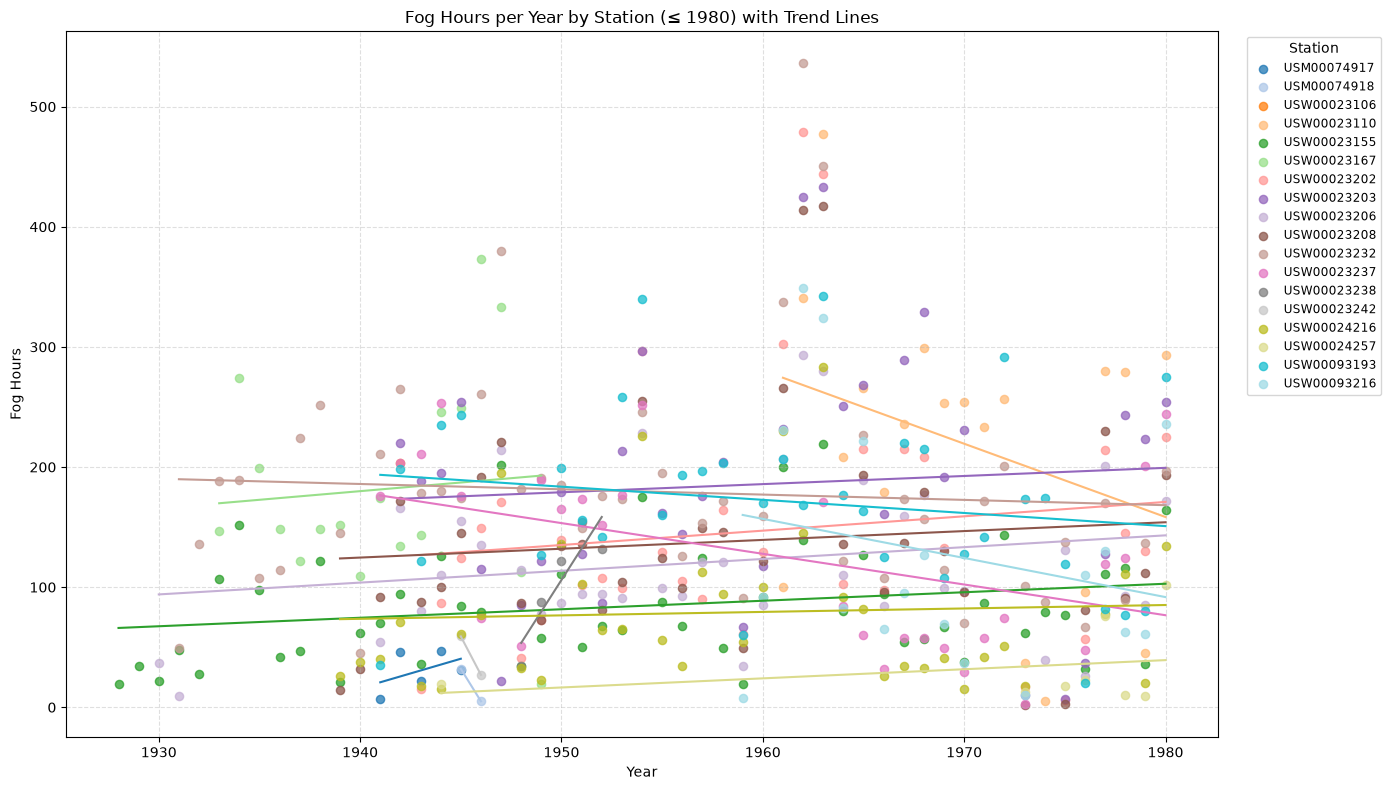

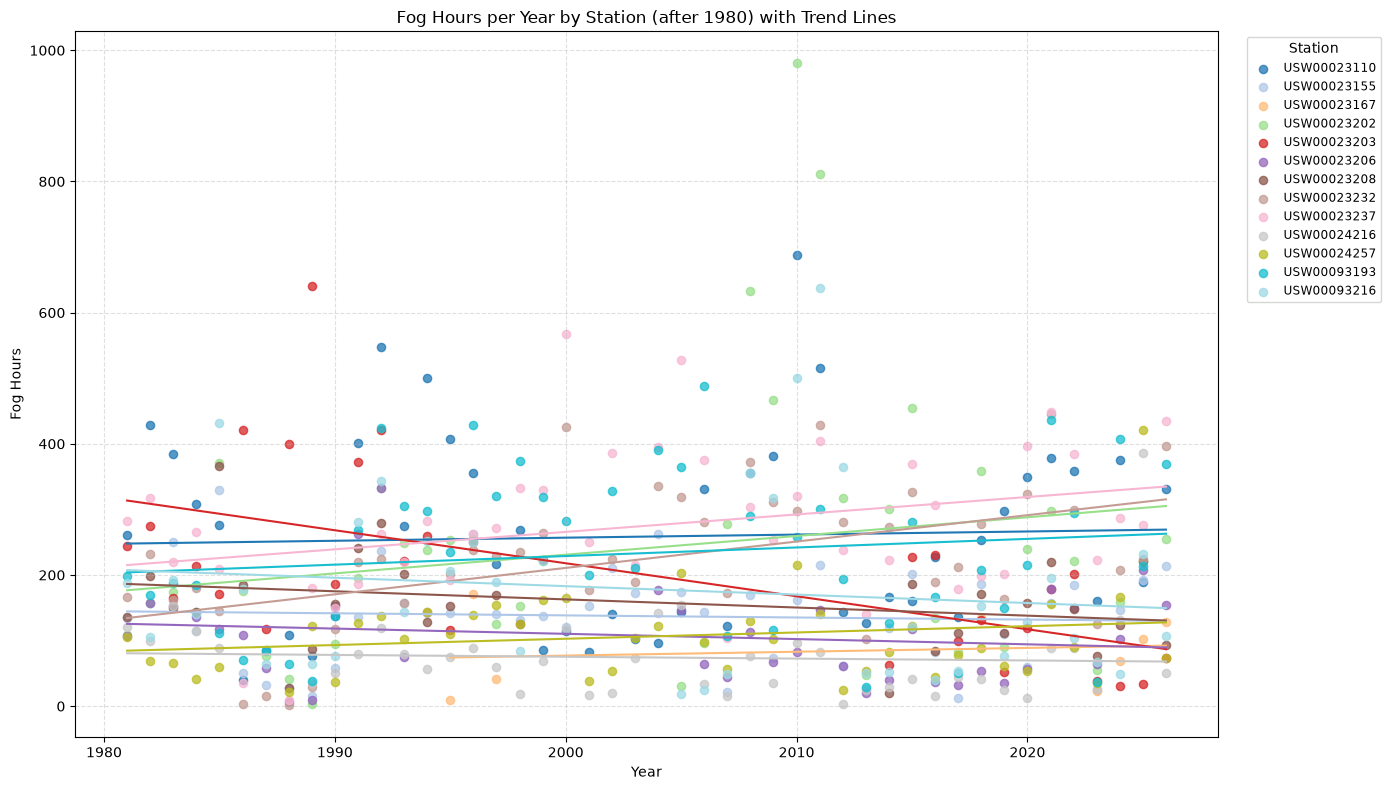

In [12]:
fog_hours_pre1970_stations = (
    CV_fog_rows[CV_fog_rows['STATION'].isin(stations_pre1970)]
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_hours')
    .sort_values(['STATION', 'year'])
)

print("fog_hours_pre1970_stations:", fog_hours_pre1970_stations.shape)
print(fog_hours_pre1970_stations.head())

fog_hours_pre1980 = fog_hours_pre1970_stations[fog_hours_pre1970_stations['year'] <= 1980]
fog_hours_post1980 = fog_hours_pre1970_stations[fog_hours_pre1970_stations['year'] > 1980]

plt.figure(figsize=(14, 8))
stations = fog_hours_pre1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_hours_pre1980[fog_hours_pre1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_hours'].to_numpy()

    plt.scatter(x, y, color=colors[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        plt.plot(x, slope * x + intercept, color=colors[i], linewidth=1.5)

plt.title('Fog Hours per Year by Station (≤ 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Hours')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

plt.figure(figsize=(14, 8))
stations = fog_hours_post1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_hours_post1980[fog_hours_post1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_hours'].to_numpy()

    plt.scatter(x, y, color=colors[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        plt.plot(x, slope * x + intercept, color=colors[i], linewidth=1.5)

plt.title('Fog Hours per Year by Station (after 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Hours')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

post_hours_fit_stats = []

for station, station_df in fog_hours_post1980.groupby('STATION'):
    station_df = station_df.sort_values('year')
    x = station_df['year'].astype(float)
    y = station_df['fog_hours'].astype(float)

    if len(station_df) >= 2:
        res = stats.linregress(x, y)
        post_hours_fit_stats.append({
            'STATION': station,
            'slope': res.slope,
            'intercept': res.intercept,
            'r_squared': res.rvalue ** 2,
            'p_value': res.pvalue,
            'stderr': res.stderr,
            'n_obs': len(station_df),
        })

post_hours_fit_stats_df = pd.DataFrame(post_hours_fit_stats).sort_values('r_squared', ascending=False)
print(post_hours_fit_stats_df[['STATION', 'slope', 'intercept', 'r_squared', 'p_value', 'n_obs']])

        STATION  avg_fog_days_per_year
20  USW00053119              61.590909
3   USW00023106              47.000000
21  USW00093144              42.090909
15  USW00023257              40.272727
29  USW00093242              39.954545
8   USW00023203              37.484375
12  USW00023237              36.175676
11  USW00023232              36.041667
4   USW00023110              34.753846
6   USW00023167              32.360000
27  USW00093225              32.142857
22  USW00093193              31.301205
16  USW00023258              30.962963
10  USW00023208              29.471429
24  USW00093205              28.333333
7   USW00023202              27.013158
0   USI0000KO32              25.800000
13  USW00023238              25.800000
9   USW00023206              24.146667
5   USW00023155              20.959596
26  USW00093216              20.948276
17  USW00023285              17.074074
25  USW00093210              16.272727
18  USW00024216              15.902439
19  USW00024257          

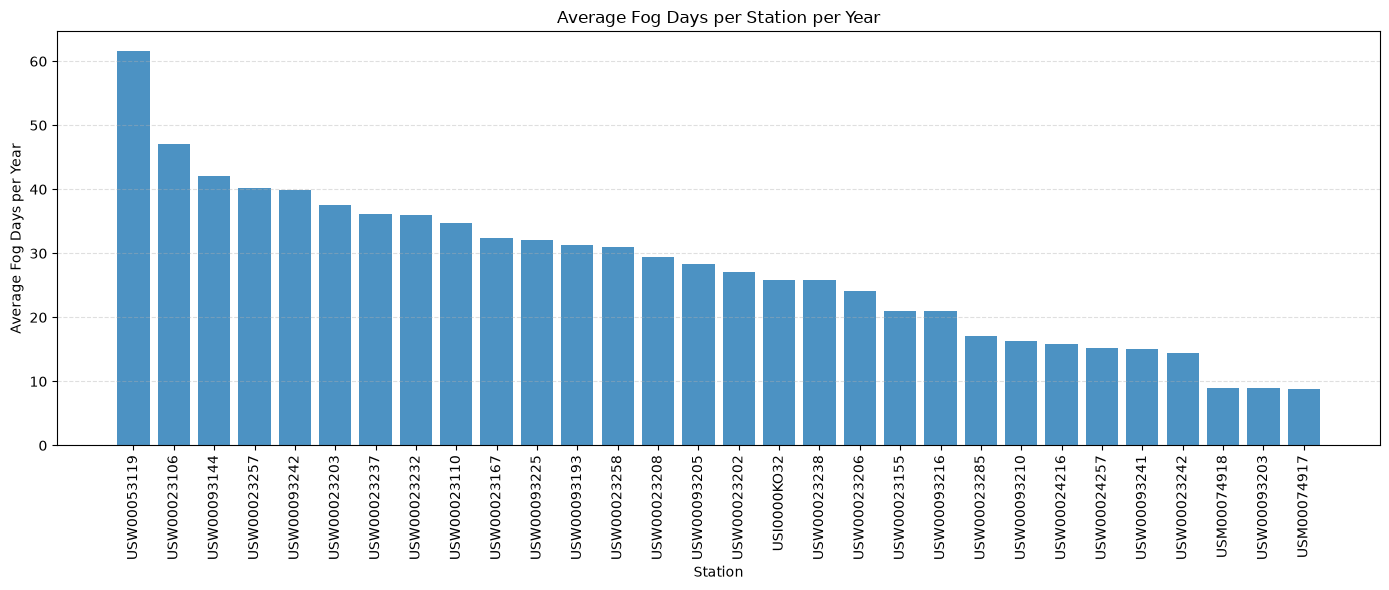

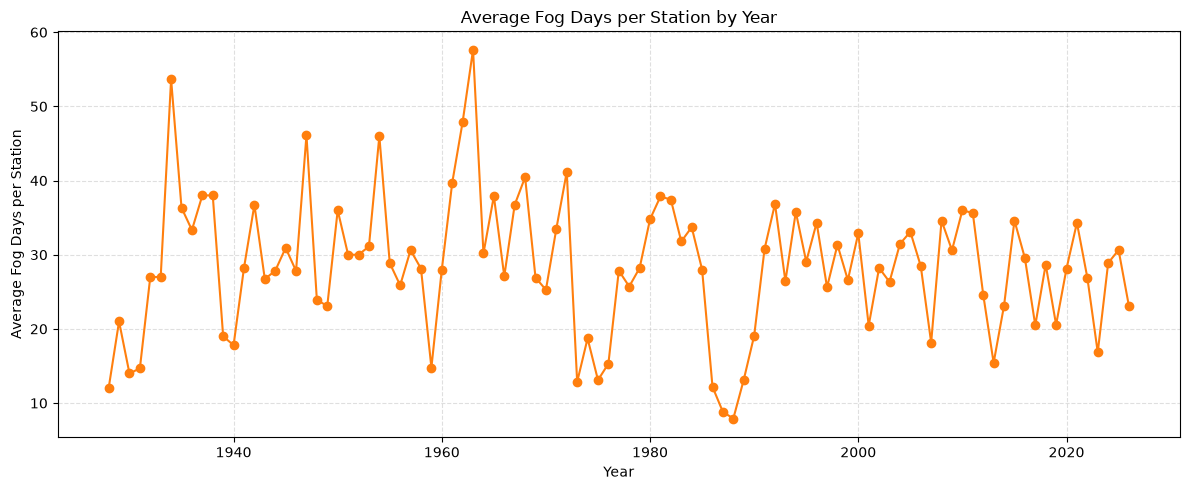

In [15]:
station_avg_fog_days = (
    fog_days_year
    .groupby('STATION', as_index=False)['fog_days']
    .mean()
    .rename(columns={'fog_days': 'avg_fog_days_per_year'})
    .sort_values('avg_fog_days_per_year', ascending=False)
)

print(station_avg_fog_days)

yearly_avg_fog_days = (
    fog_days_year
    .groupby('year', as_index=False)['fog_days']
    .mean()
    .rename(columns={'fog_days': 'avg_fog_days_per_station'})
)

plt.figure(figsize=(14, 6))
plt.bar(
    station_avg_fog_days['STATION'],
    station_avg_fog_days['avg_fog_days_per_year'],
    color='tab:blue',
    alpha=0.8
)
plt.xticks(rotation=90)
plt.title('Average Fog Days per Station per Year')
plt.xlabel('Station')
plt.ylabel('Average Fog Days per Year')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(
    yearly_avg_fog_days['year'],
    yearly_avg_fog_days['avg_fog_days_per_station'],
    marker='o',
    linestyle='-',
    color='tab:orange'
)
plt.title('Average Fog Days per Station by Year')
plt.xlabel('Year')
plt.ylabel('Average Fog Days per Station')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

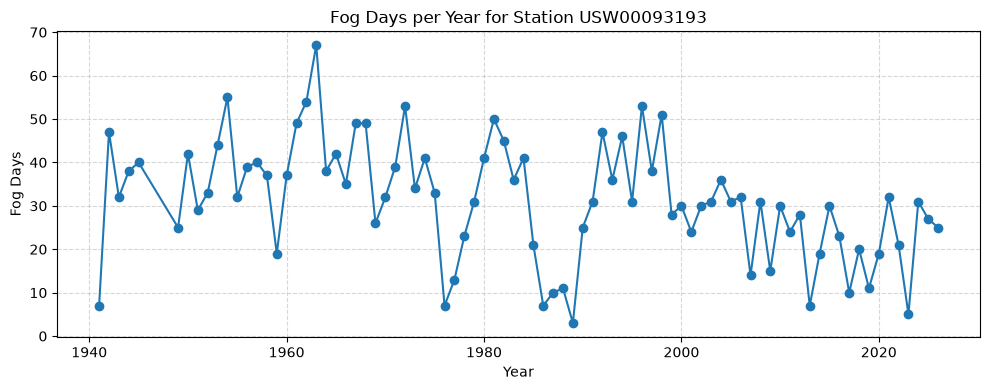

In [16]:
station = 'USW00093193'
station_df = fog_days_year[fog_days_year['STATION'] == station].sort_values('year')

plt.figure(figsize=(10, 4))
plt.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-')
plt.title(f'Fog Days per Year for Station {station}')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
fog_hours_year = CV_fog_rows.groupby(['STATION', 'year']).size().reset_index(name='fog_hours')

fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_days')
)

fog_avg_hours_per_day = fog_hours_year.merge(fog_days_year, on=['STATION', 'year'])
fog_avg_hours_per_day['avg_fog_hours_per_day'] = (
    fog_avg_hours_per_day['fog_hours'] / fog_avg_hours_per_day['fog_days']
)

fog_avg_hours_per_day = fog_avg_hours_per_day.sort_values(['STATION', 'year']).reset_index(drop=True)
print(fog_avg_hours_per_day.head(20))

        STATION  year  fog_hours  fog_days  avg_fog_hours_per_day
0   USI0000KO32  2018         43        10               4.300000
1   USI0000KO32  2023        173        22               7.863636
2   USI0000KO32  2024        303        38               7.973684
3   USI0000KO32  2025        240        36               6.666667
4   USI0000KO32  2026        298        23              12.956522
5   USM00074917  1941          7         3               2.333333
6   USM00074917  1942         46        15               3.066667
7   USM00074917  1943         22         7               3.142857
8   USM00074917  1944         47        12               3.916667
9   USM00074917  1945         31         7               4.428571
10  USM00074918  1945         32        15               2.133333
11  USM00074918  1946          5         3               1.666667
12  USW00023106  1942        203        47               4.319149
13  USW00023110  1961        100        20               5.000000
14  USW000

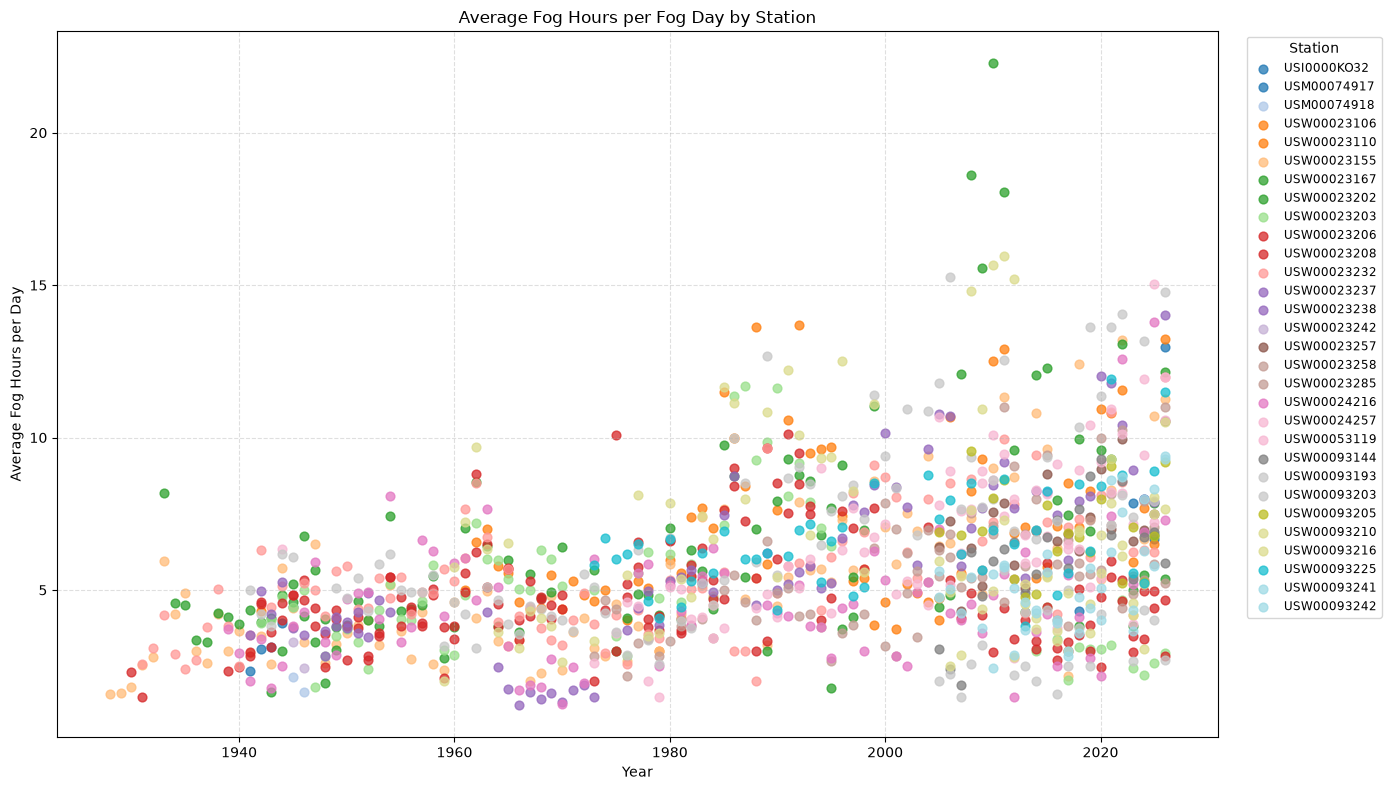

In [14]:
plt.figure(figsize=(14, 8))

stations = fog_avg_hours_per_day['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_avg_hours_per_day[fog_avg_hours_per_day['STATION'] == station].sort_values('year')
    plt.scatter(
        station_df['year'],
        station_df['avg_fog_hours_per_day'],
        color=colors[i % len(colors)],
        label=station,
        s=40,
        alpha=0.75
    )

plt.title('Average Fog Hours per Fog Day by Station')
plt.xlabel('Year')
plt.ylabel('Average Fog Hours per Day')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

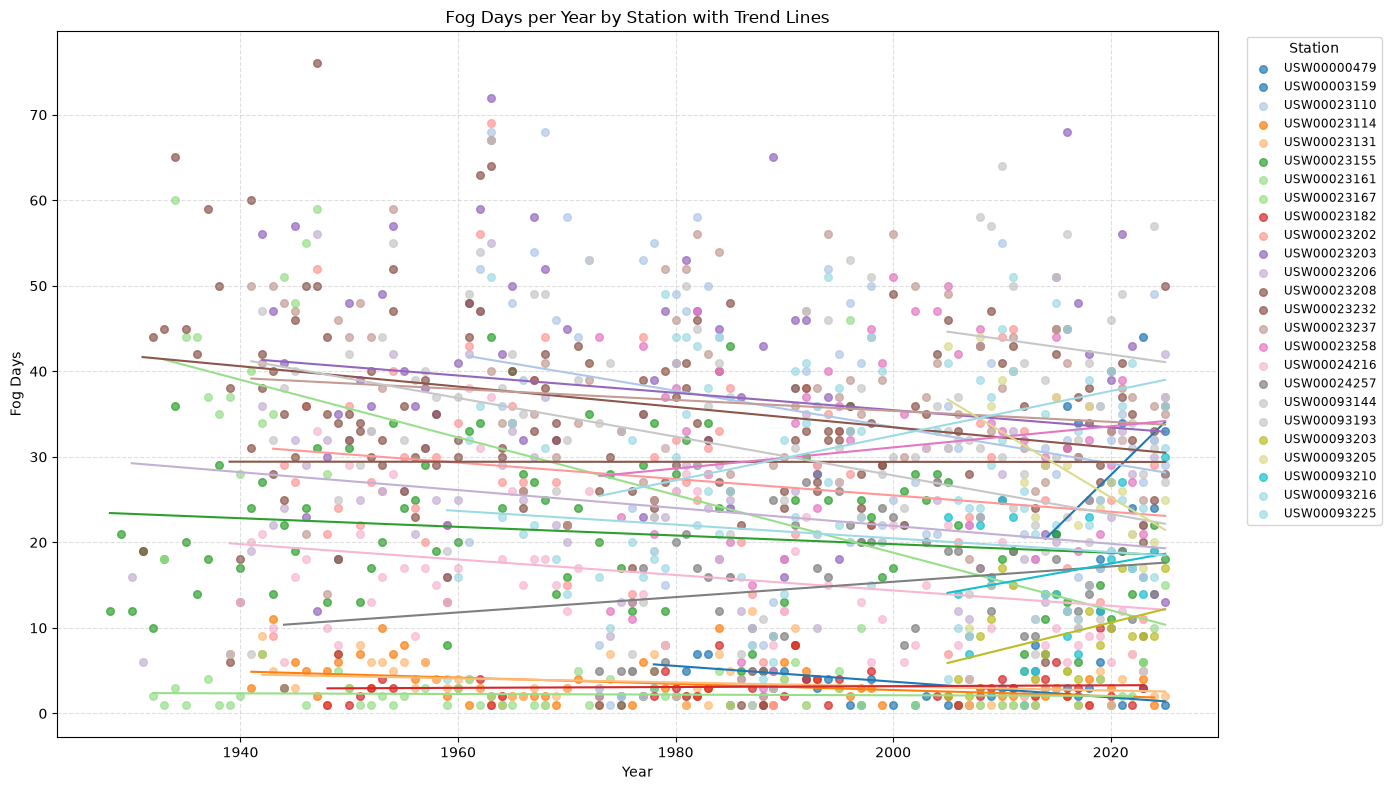

In [33]:
plt.figure(figsize=(14, 8))

stations = fog_days_year['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_year[fog_days_year['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors[i % len(colors)], label=station, s=30, alpha=0.7)

    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors[i % len(colors)], linewidth=1.5)

plt.title('Fog Days per Year by Station with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

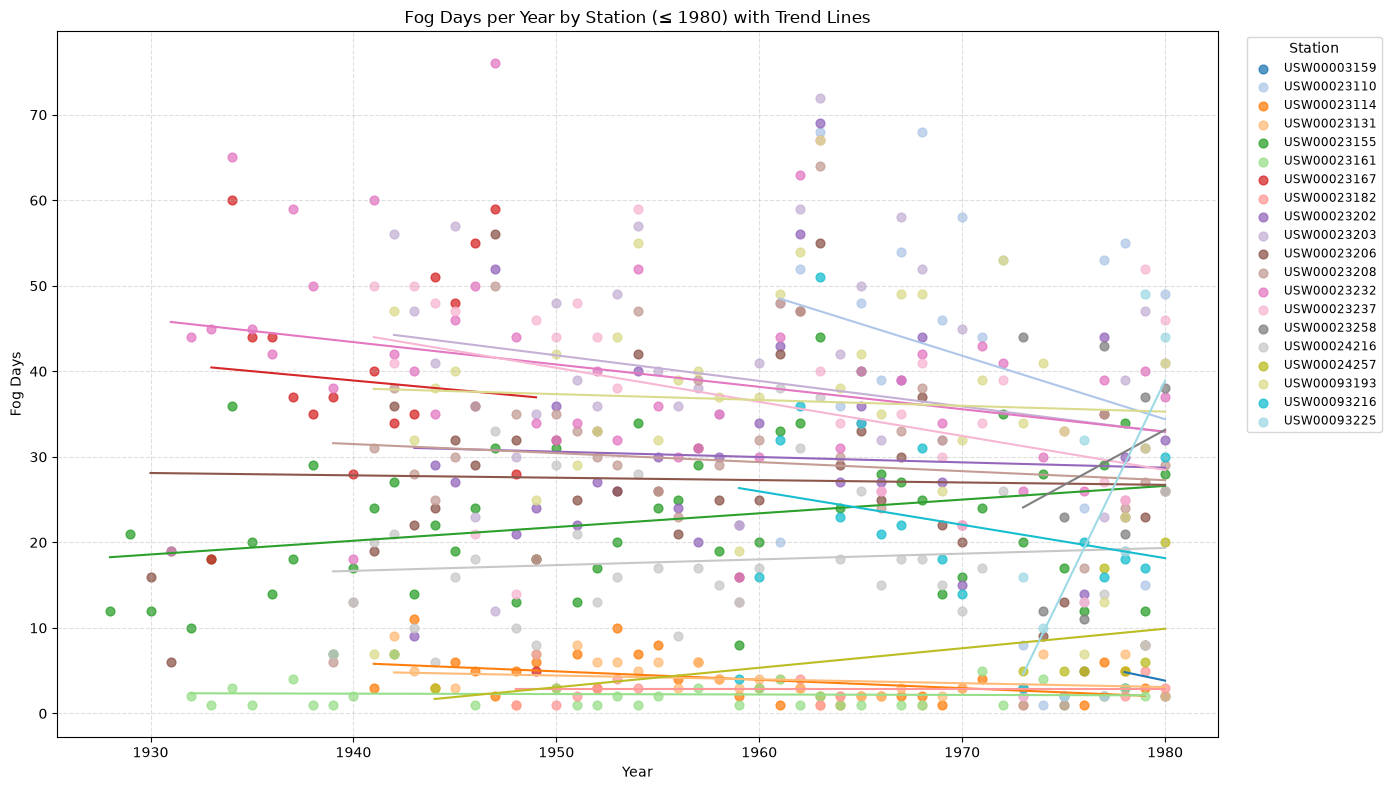

In [34]:
fog_days_pre1980 = fog_days_year[fog_days_year['year'] <= 1980]

plt.figure(figsize=(14, 8))
stations = fog_days_pre1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_pre1980[fog_days_pre1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors[i], label=station, s=40, alpha=0.75)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors[i], linewidth=1.5)

plt.title('Fog Days per Year by Station (≤ 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

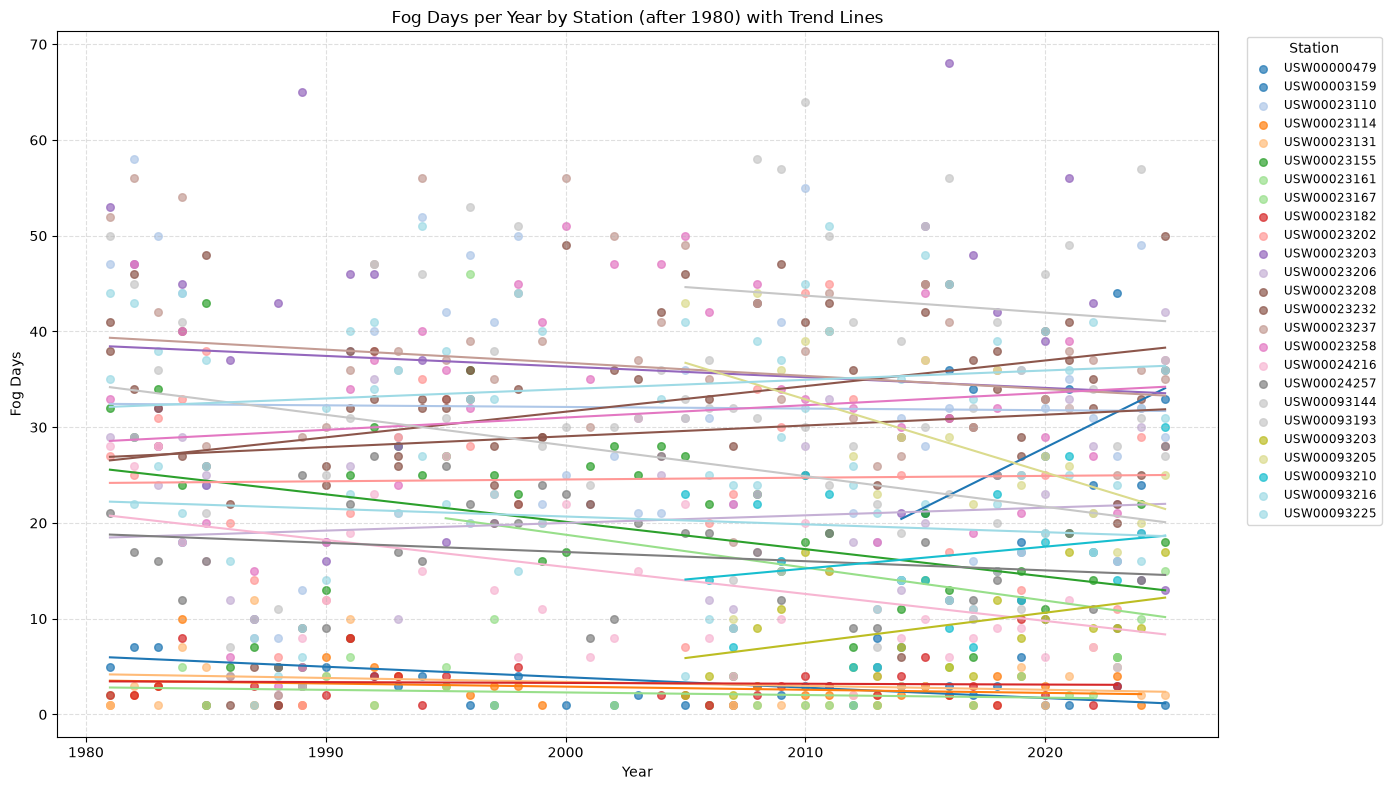

In [35]:
fog_days_post1980 = fog_days_year[fog_days_year['year'] > 1980]

plt.figure(figsize=(14, 8))

stations = fog_days_post1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_post1980[fog_days_post1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors[i % len(colors)], label=station, s=30, alpha=0.7)

    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors[i % len(colors)], linewidth=1.5)

plt.title('Fog Days per Year by Station (after 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

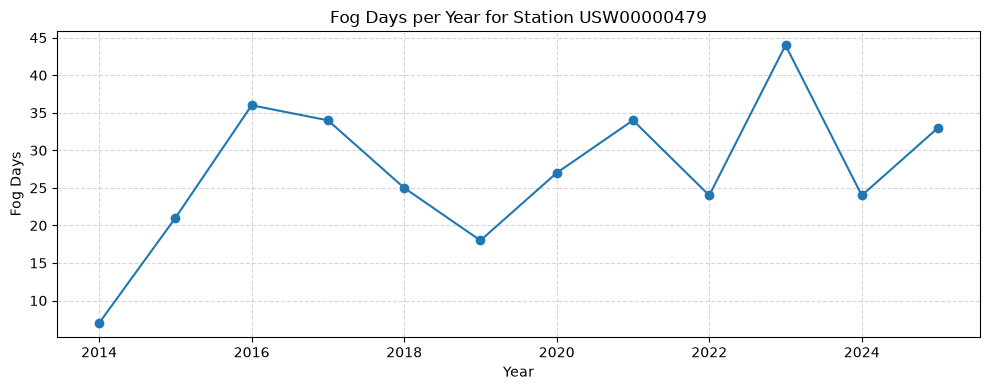

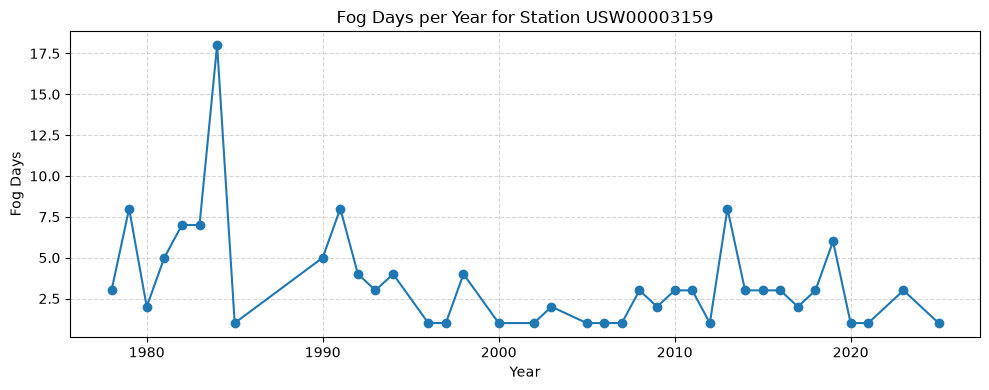

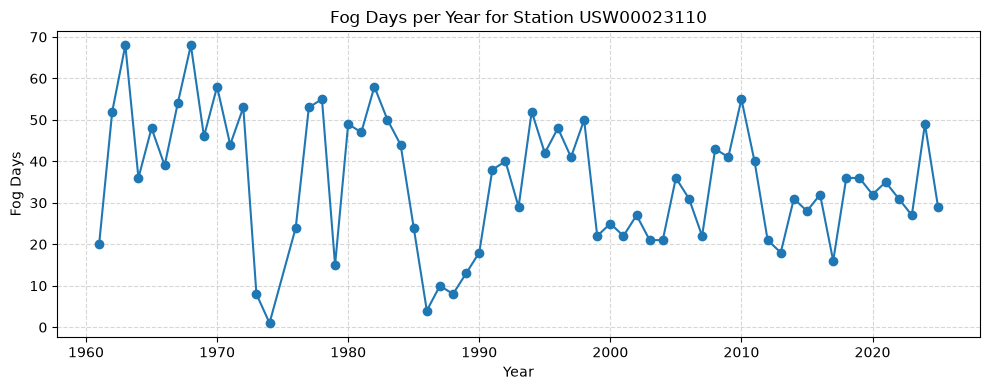

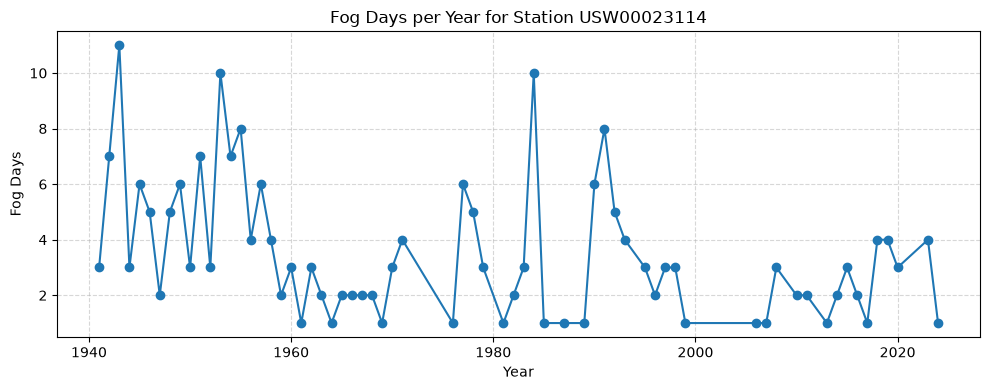

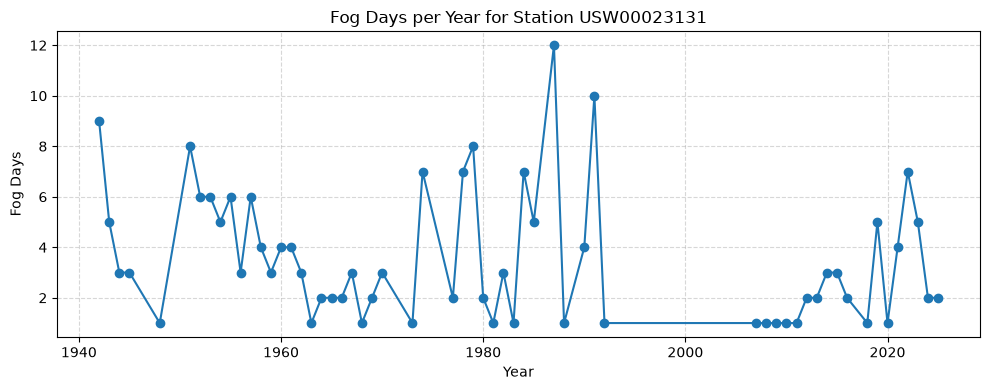

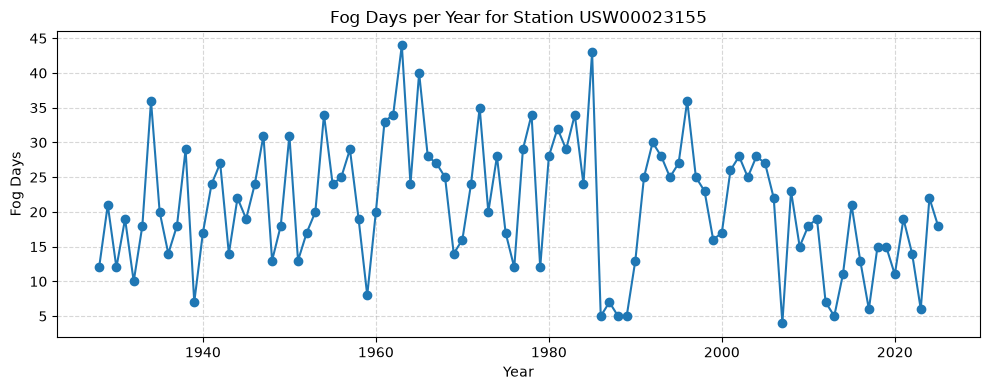

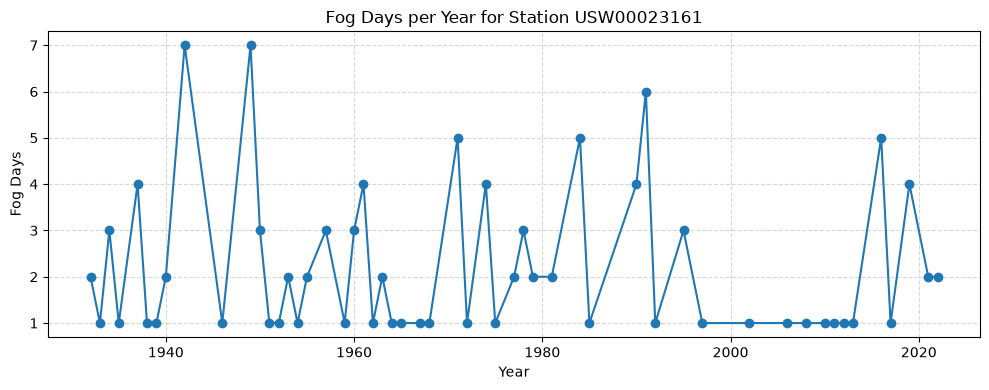

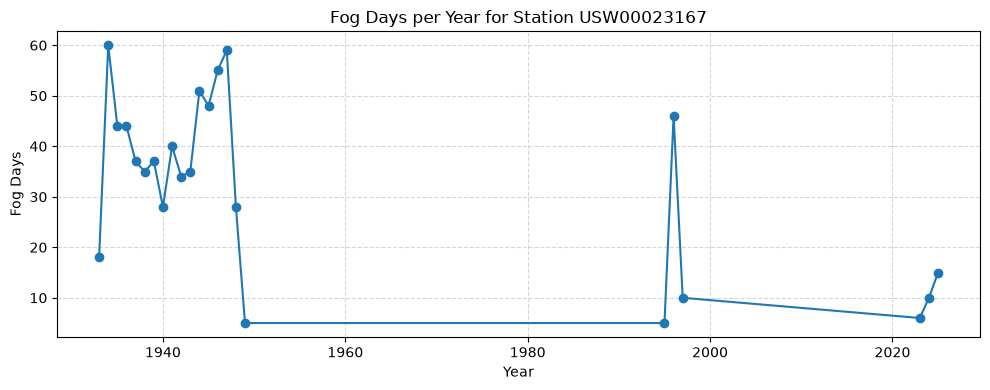

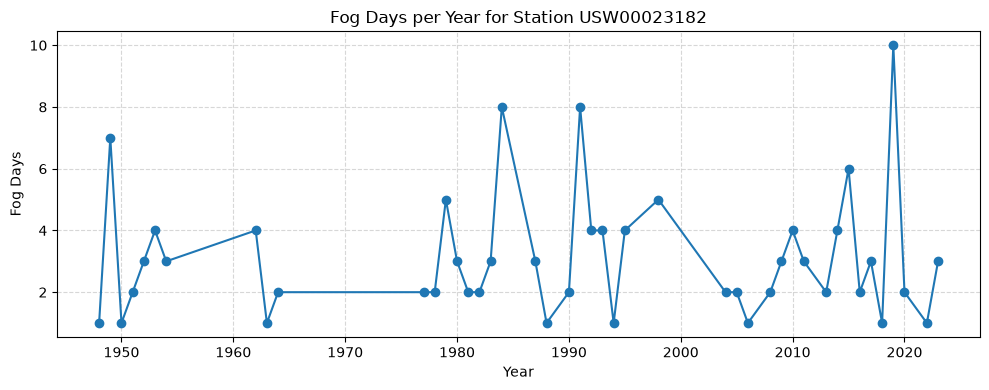

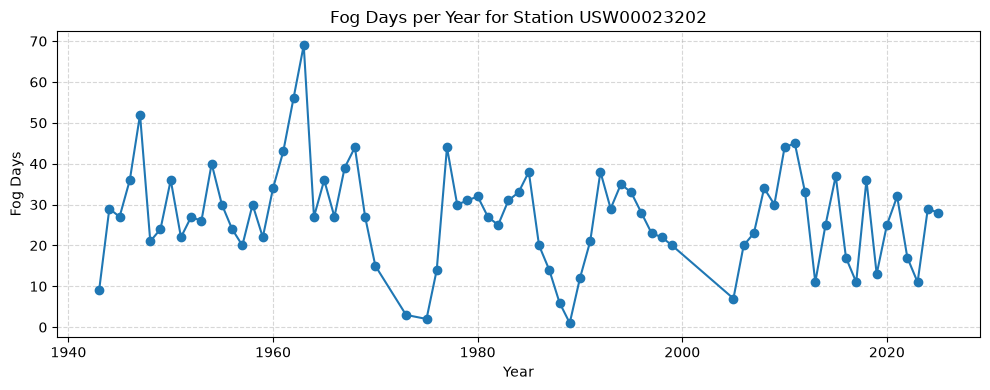

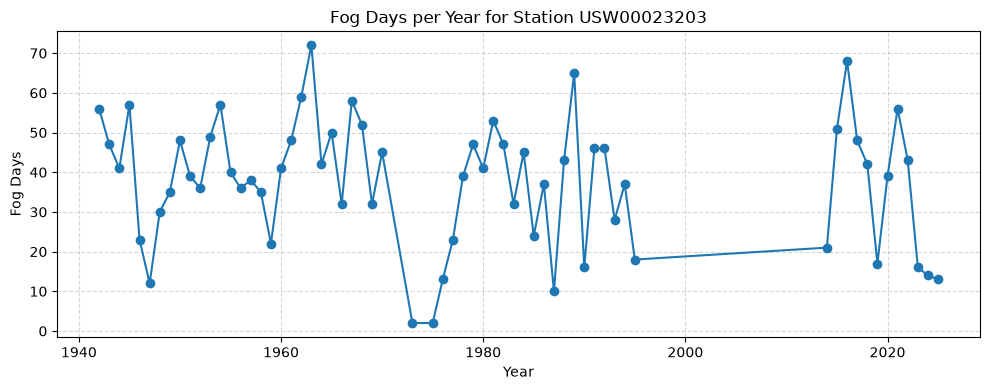

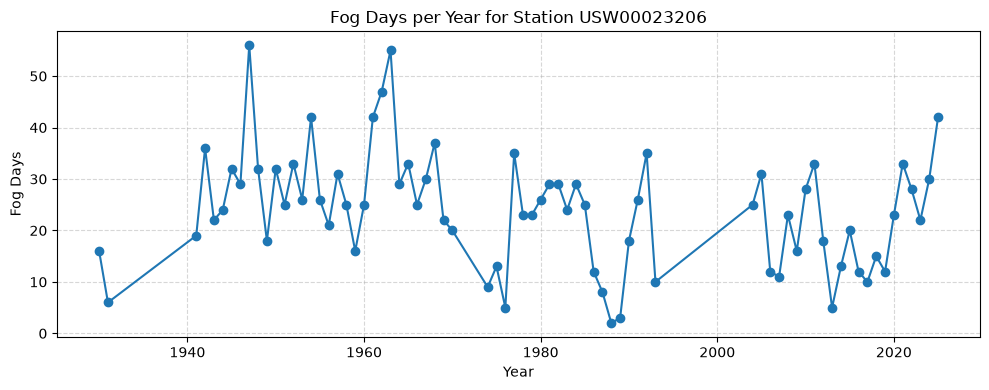

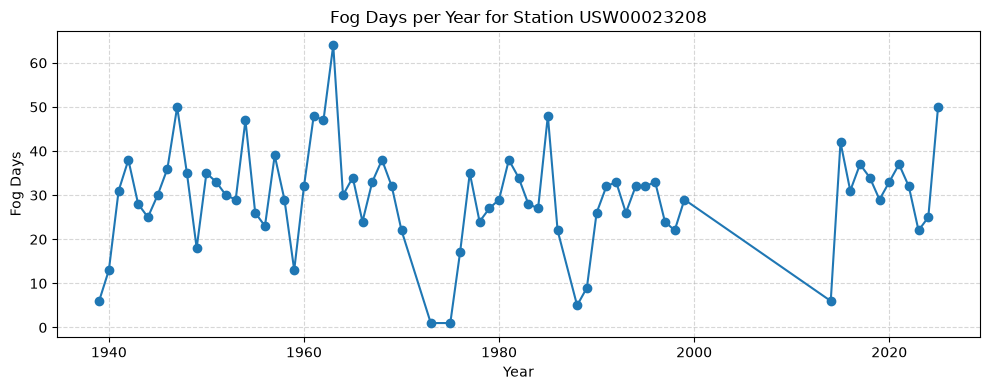

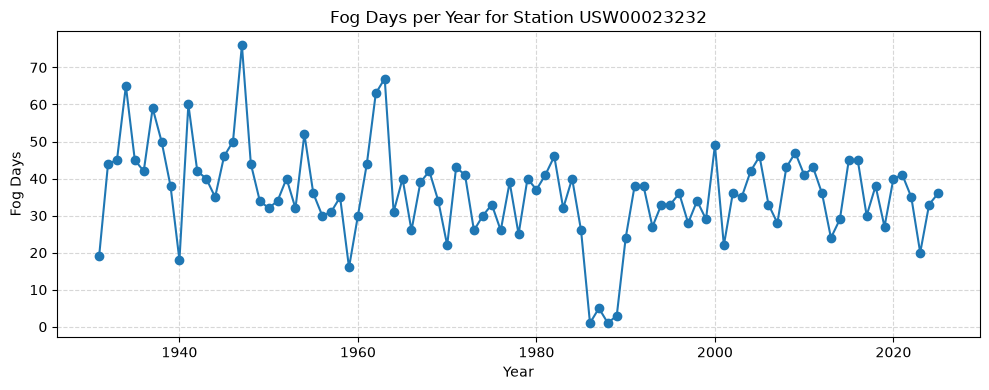

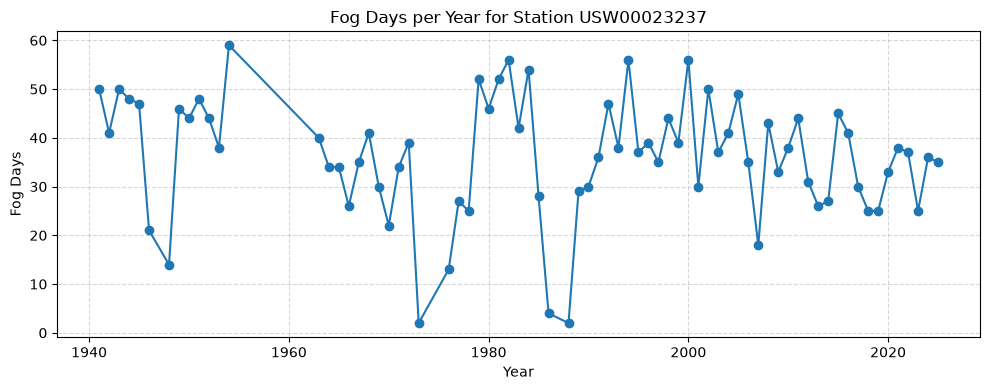

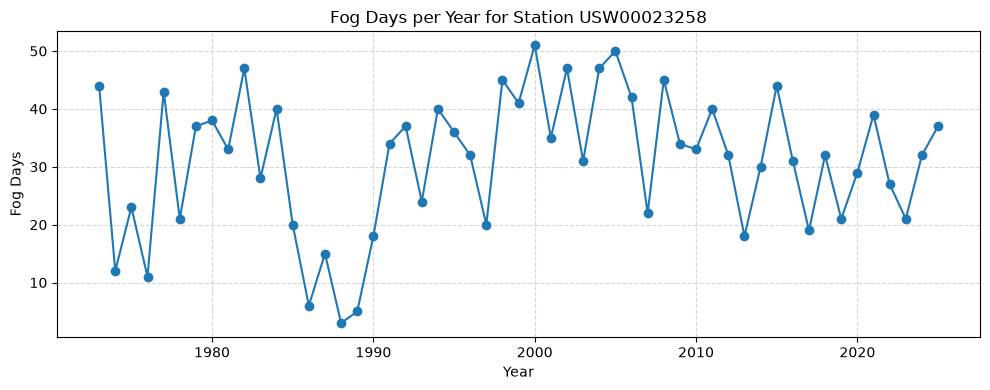

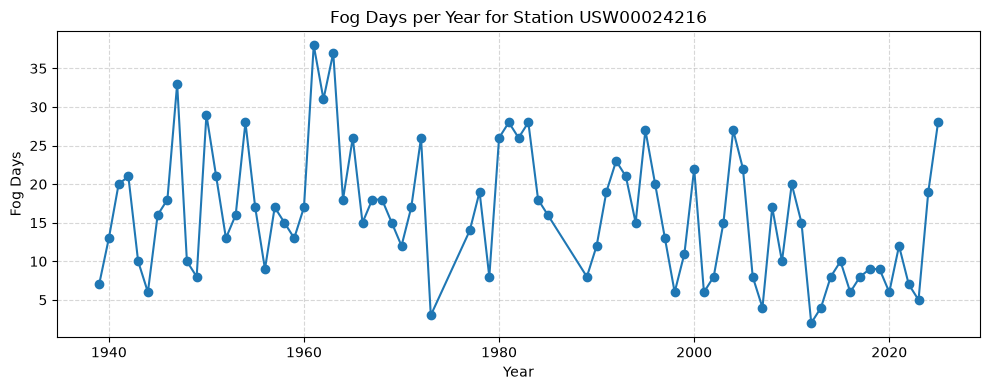

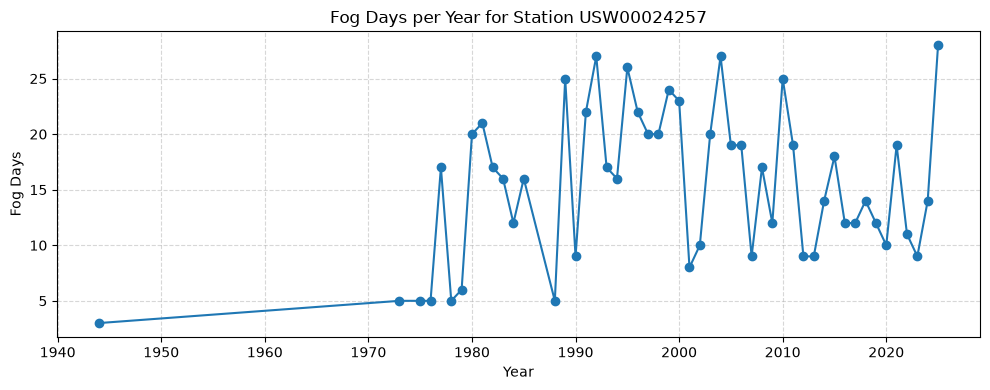

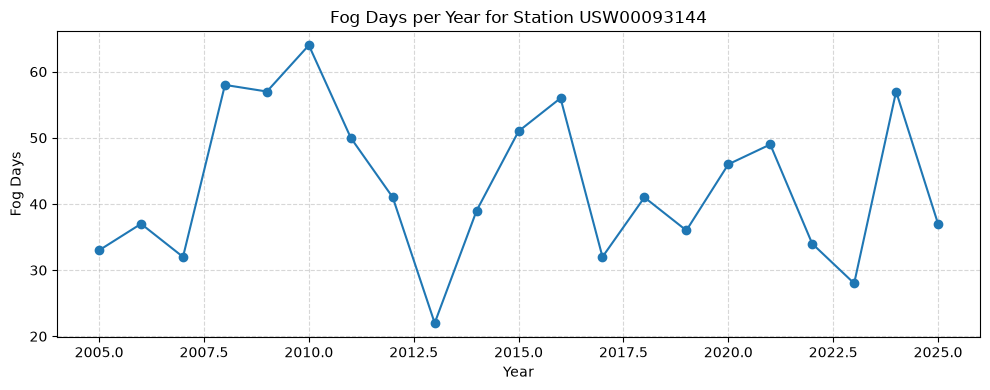

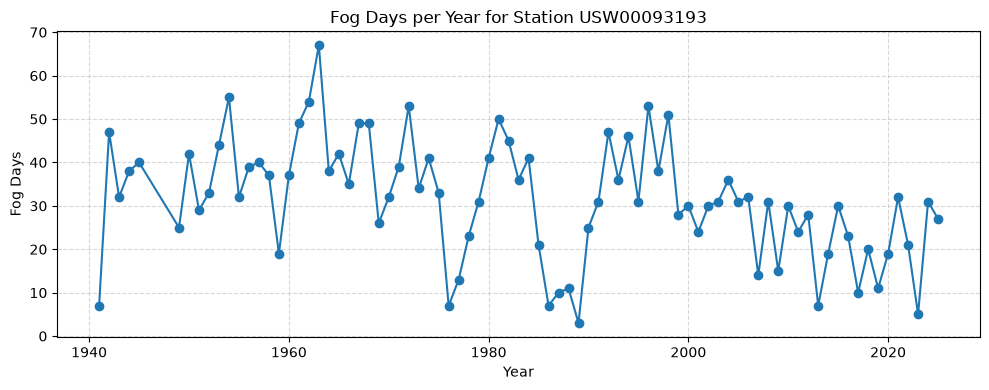

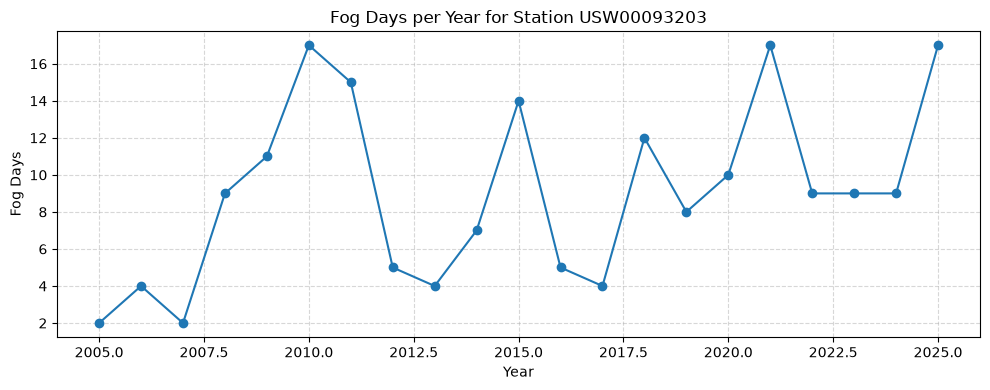

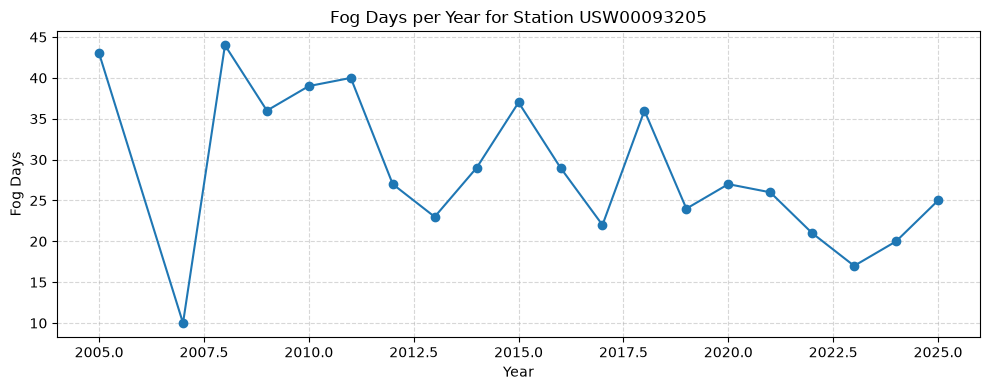

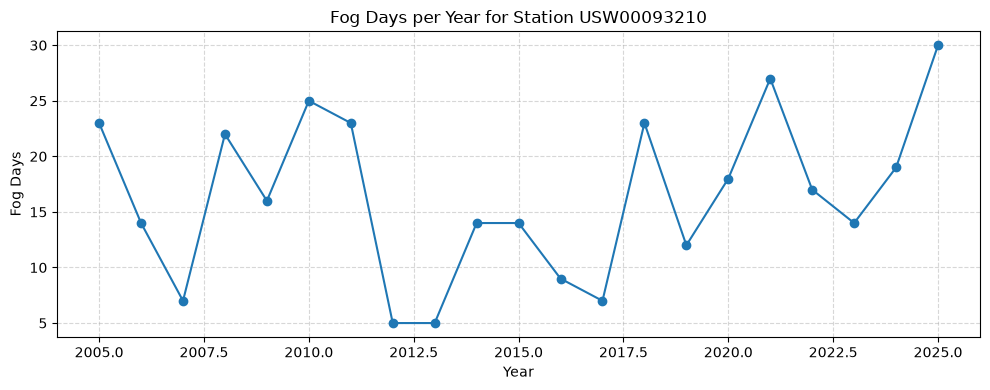

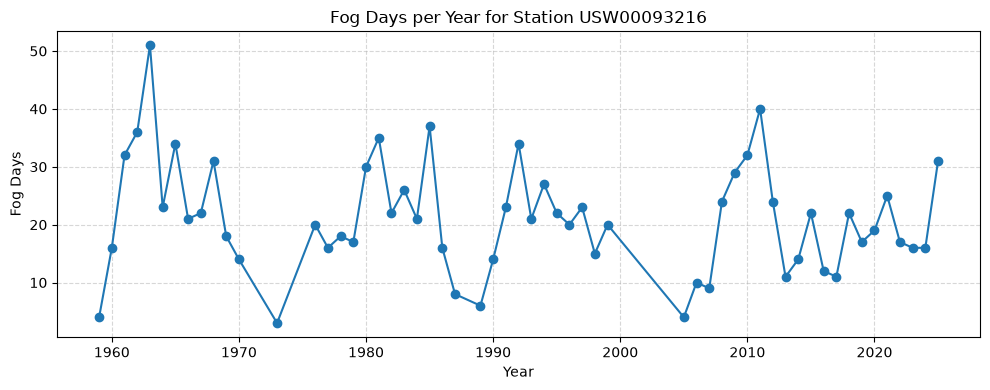

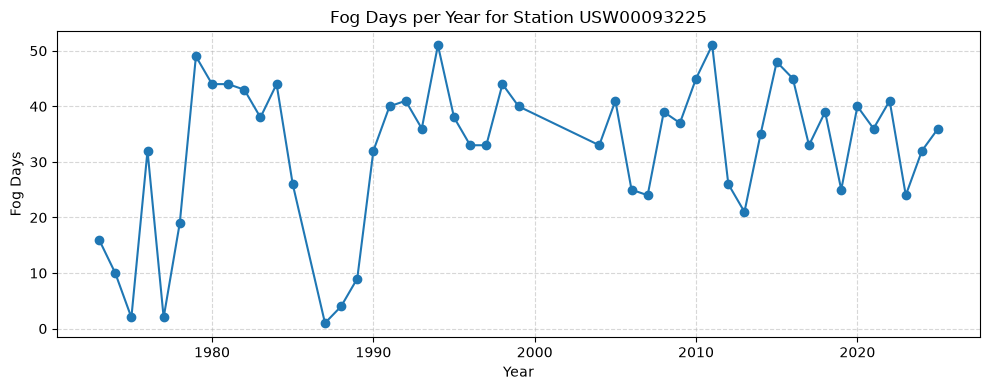

In [32]:
for station in fog_days_year['STATION'].unique():
    station_df = fog_days_year[fog_days_year['STATION'] == station].sort_values('year')
    plt.figure(figsize=(10, 4))
    plt.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-')
    plt.title(f'Fog Days per Year for Station {station}')
    plt.xlabel('Year')
    plt.ylabel('Fog Days')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [29]:
fog_hours_per_year = CV_fog_rows.groupby('year').size().rename('fog_hours')
fog_days_per_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby('year')
    .size()
    .rename('fog_days')
)

fog_summary = pd.concat([fog_hours_per_year, fog_days_per_year], axis=1).reset_index()
print(fog_summary)

densefog_hours_per_year = CV_densefog_rows.groupby('year').size().rename('densefog_hours')
densefog_days_per_year = (
    CV_densefog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby('year')
    .size()
    .rename('densefog_days')
)

densefog_summary = pd.concat([densefog_hours_per_year, densefog_days_per_year], axis=1).reset_index()
print(densefog_summary)

    year  fog_hours  fog_days
0   1928         19        12
1   1929         34        21
2   1930         59        28
3   1931        106        44
4   1932        169        56
..   ...        ...       ...
93  2021       5027       614
94  2022       3833       476
95  2023       1737       362
96  2024       3400       524
97  2025       4365       598

[98 rows x 3 columns]
    year  densefog_hours  densefog_days
0   1928               3              3
1   1929              13             11
2   1930              18             13
3   1931              62             28
4   1932              61             34
..   ...             ...            ...
93  2021            3506            529
94  2022            2684            400
95  2023            1066            275
96  2024            2223            419
97  2025            2689            480

[98 rows x 3 columns]


In [17]:
threshold = pd.Timedelta(hours=1.5)

for df in (CV_fog_rows, CV_densefog_rows):
    df['DATE'] = pd.to_datetime(df['DATE'])
    df.sort_values(['STATION', 'DATE'], inplace=True)
    df['time_diff'] = df.groupby('STATION')['DATE'].diff()
    df['new_event'] = df['time_diff'] > threshold
    df['event_id'] = df.groupby('STATION')['new_event'].cumsum().astype(int)
    df['station_event_id'] = df['STATION'] + '_' + df['event_id'].astype(str)

CV_fog_events = (
    CV_fog_rows.groupby(['STATION', 'event_id'])
    .agg(
        start=('DATE', 'first'),
        end=('DATE', 'last'),
        records=('DATE', 'size')
    )
    .assign(
        duration_hours=lambda x: (x['end'] - x['start']) / pd.Timedelta(hours=1),
        fog_hours=lambda x: x['records']
    )
    .reset_index()
)

CV_densefog_events = (
    CV_densefog_rows.groupby(['STATION', 'event_id'])
    .agg(
        start=('DATE', 'first'),
        end=('DATE', 'last'),
        records=('DATE', 'size')
    )
    .assign(
        duration_hours=lambda x: (x['end'] - x['start']) / pd.Timedelta(hours=1),
        densefog_hours=lambda x: x['records']
    )
    .reset_index()
)

print("Fog events:", CV_fog_events.shape)
print("Dense fog events:", CV_densefog_events.shape)
print(CV_fog_events.head())
print(CV_densefog_events.head())

Fog events: (45494, 7)
Dense fog events: (36777, 7)
       STATION  event_id               start                 end  records  \
0  USW00000479         0 2014-11-13 09:55:00 2014-11-13 12:35:00        6   
1  USW00000479         1 2014-11-14 08:35:00 2014-11-14 08:35:00        1   
2  USW00000479         2 2014-11-21 21:15:00 2014-11-21 21:35:00        2   
3  USW00000479         3 2014-11-22 00:15:00 2014-11-22 00:15:00        1   
4  USW00000479         4 2014-11-22 22:15:00 2014-11-22 22:15:00        1   

   duration_hours  fog_hours  
0        2.666667          6  
1        0.000000          1  
2        0.333333          2  
3        0.000000          1  
4        0.000000          1  
       STATION  event_id               start                 end  records  \
0  USW00000479         0 2014-11-13 10:55:00 2014-11-13 10:55:00        1   
1  USW00000479         1 2014-11-13 12:35:00 2014-11-13 12:35:00        1   
2  USW00000479         2 2014-11-21 21:15:00 2014-11-21 21:15:00    

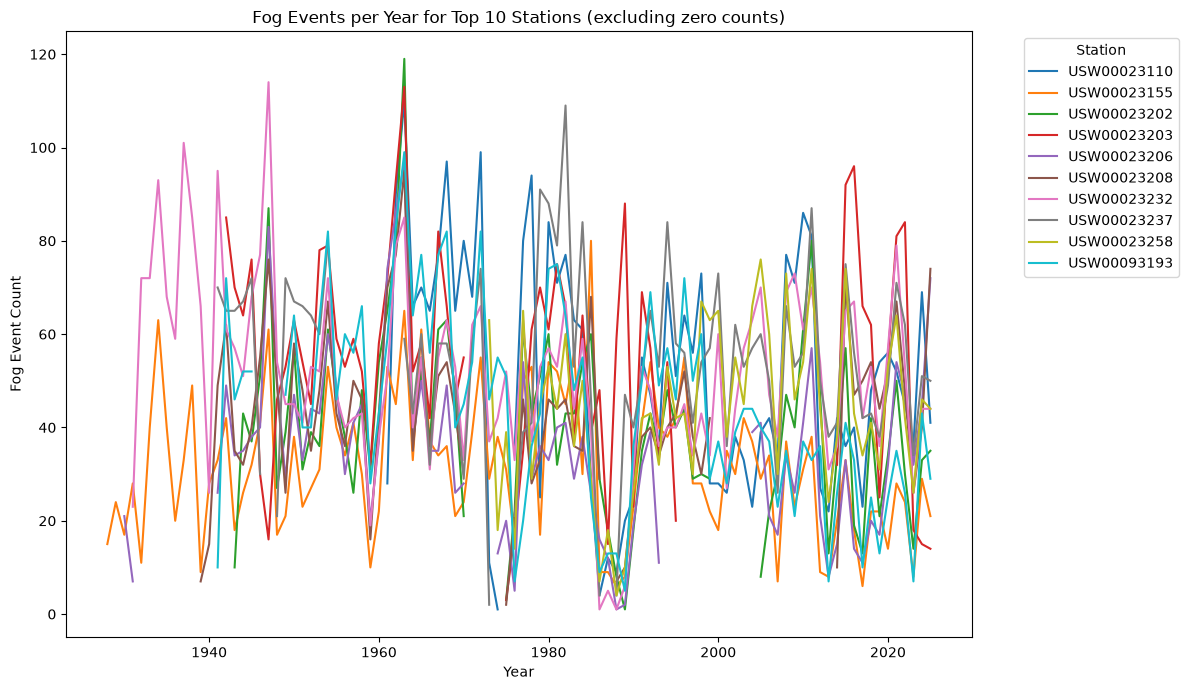

In [31]:
plot_df_nozeros = plot_df.replace(0, np.nan)

plot_df_nozeros.plot(figsize=(12, 7))
plt.title('Fog Events per Year for Top 10 Stations (excluding zero counts)')
plt.xlabel('Year')
plt.ylabel('Fog Event Count')
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_14308\763379612.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


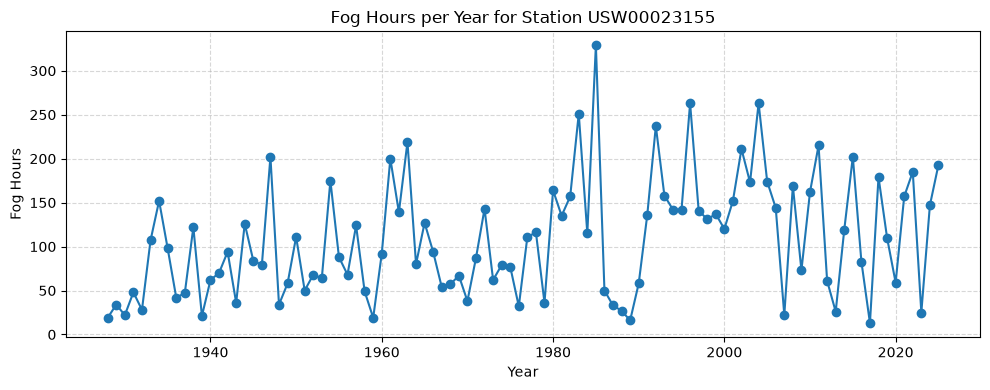

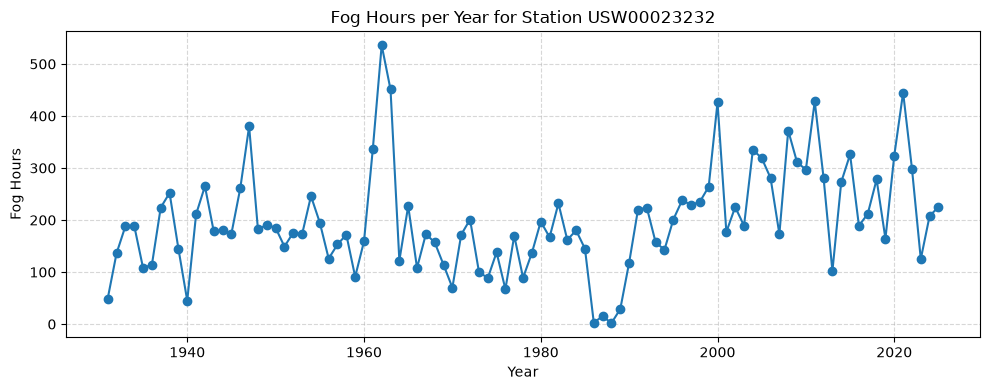

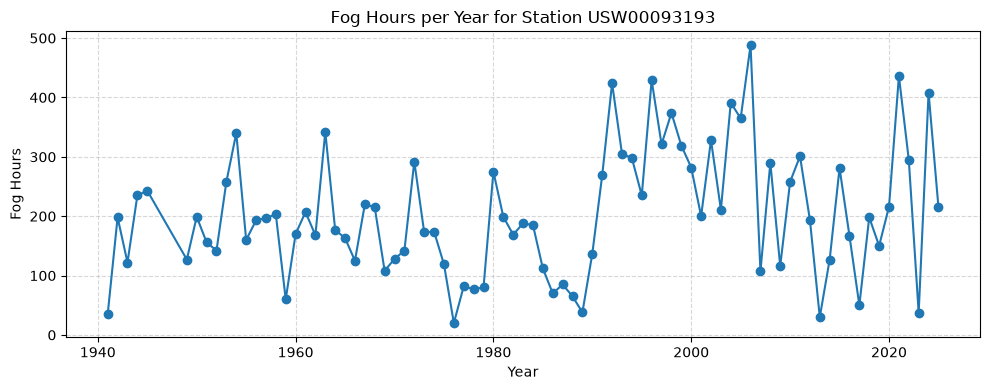

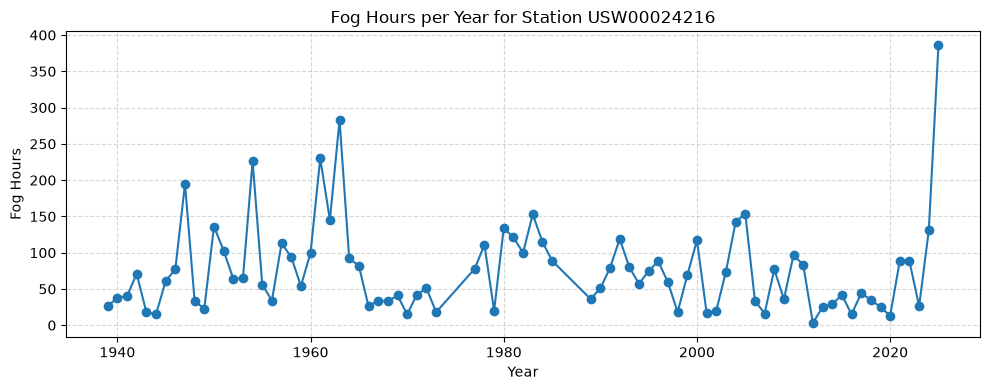

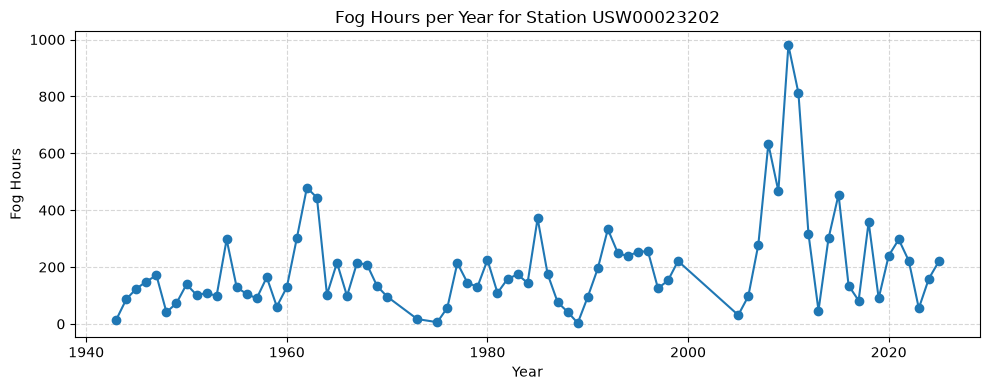

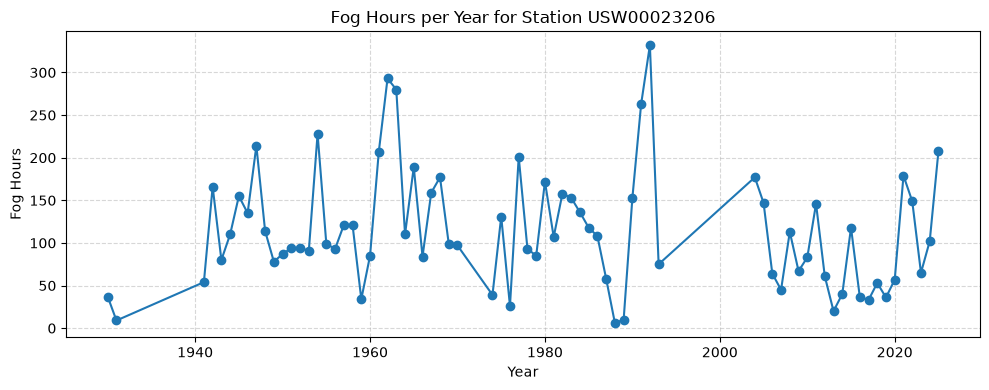

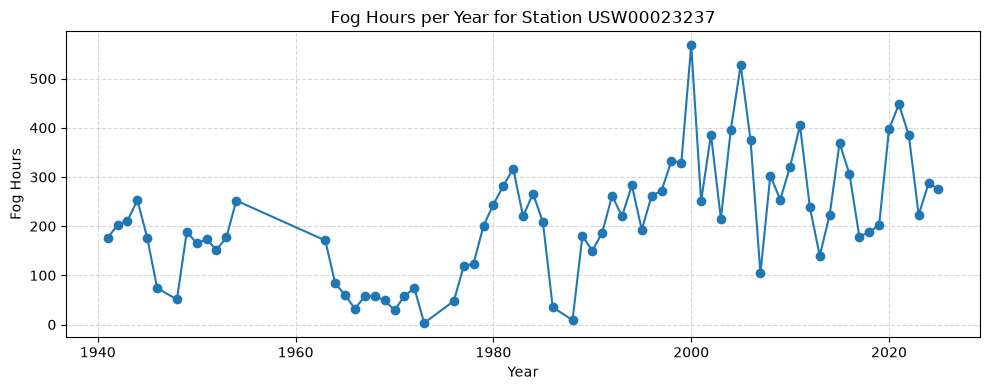

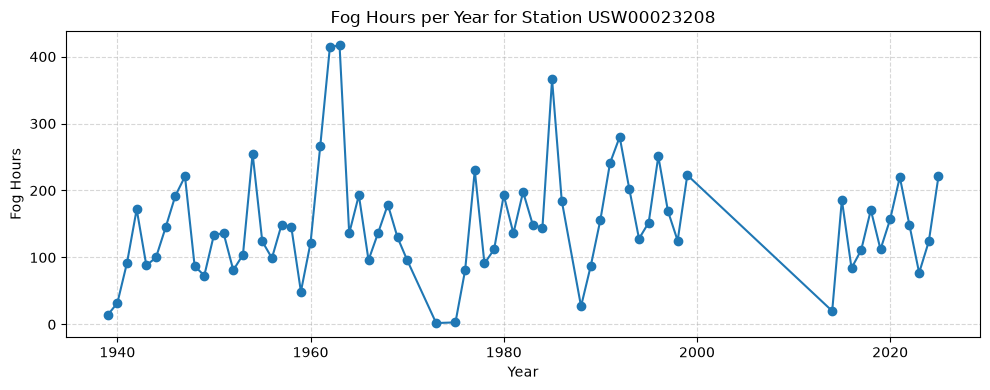

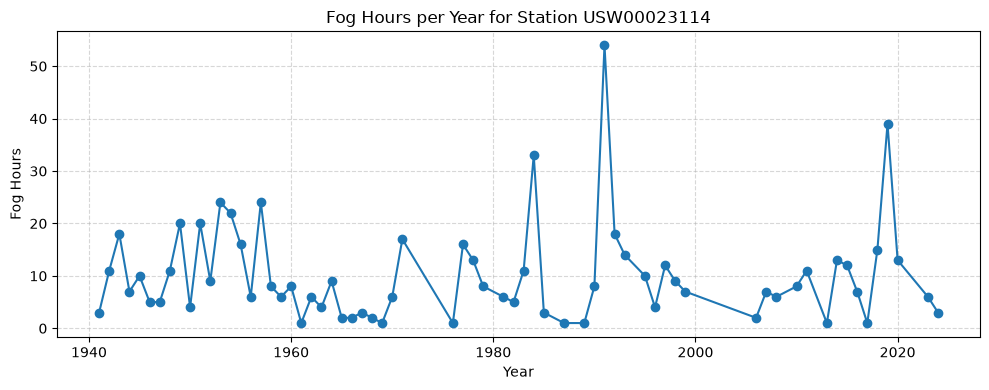

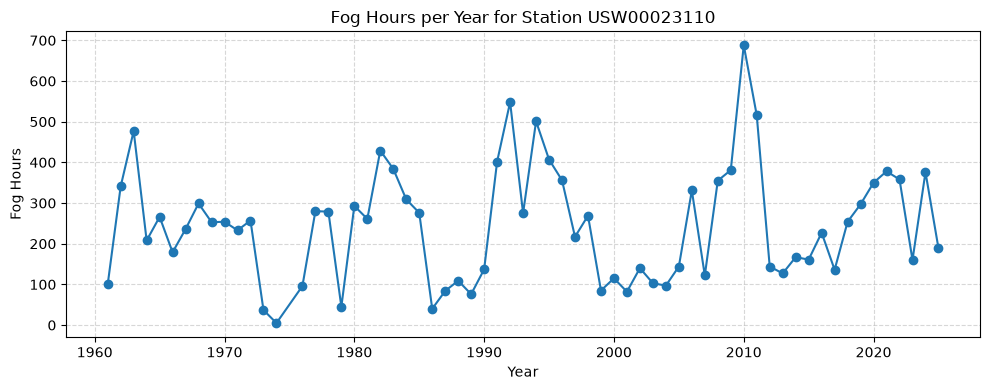

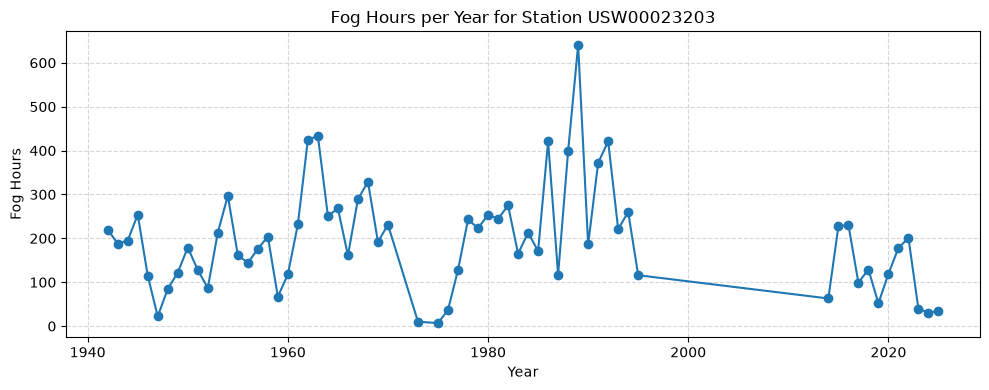

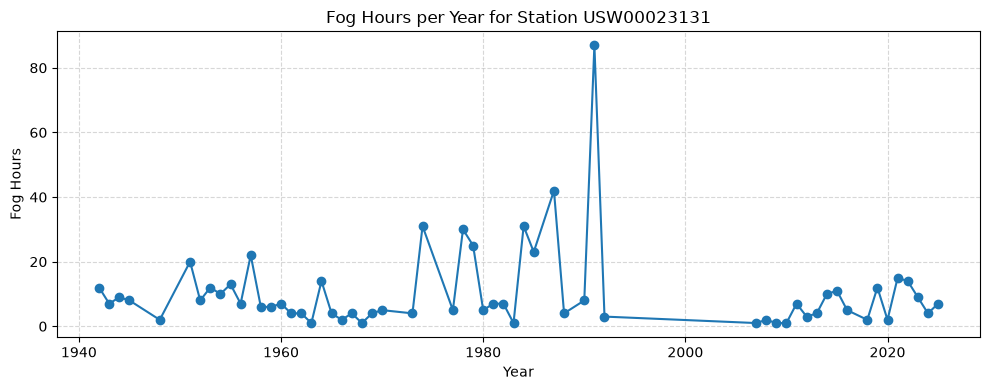

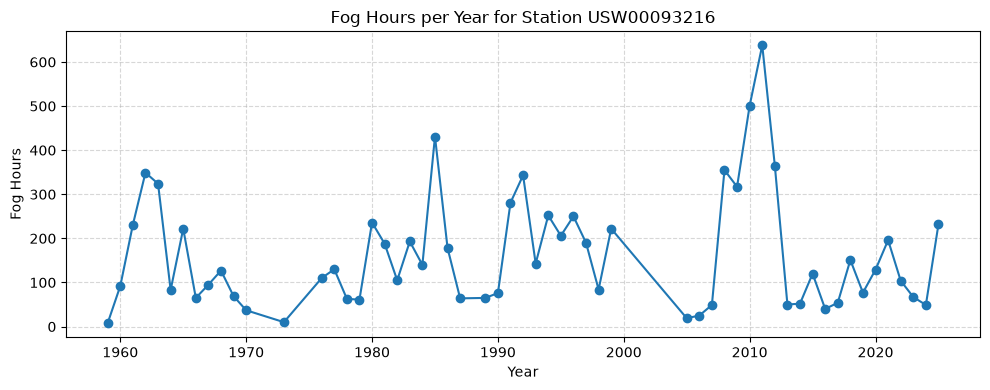

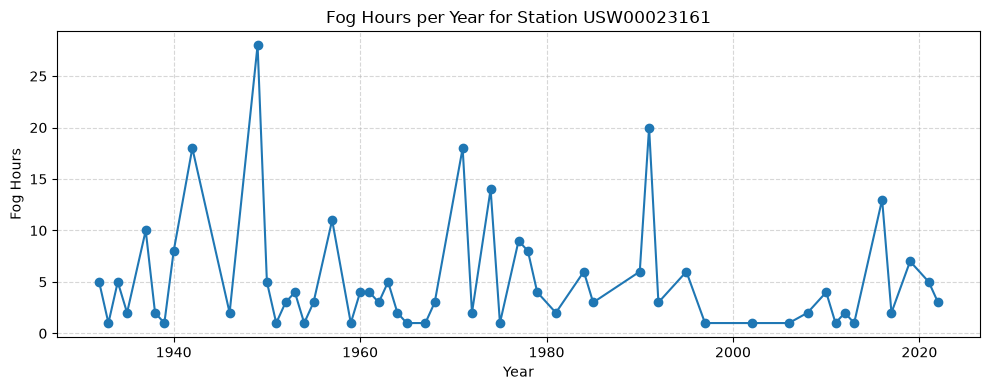

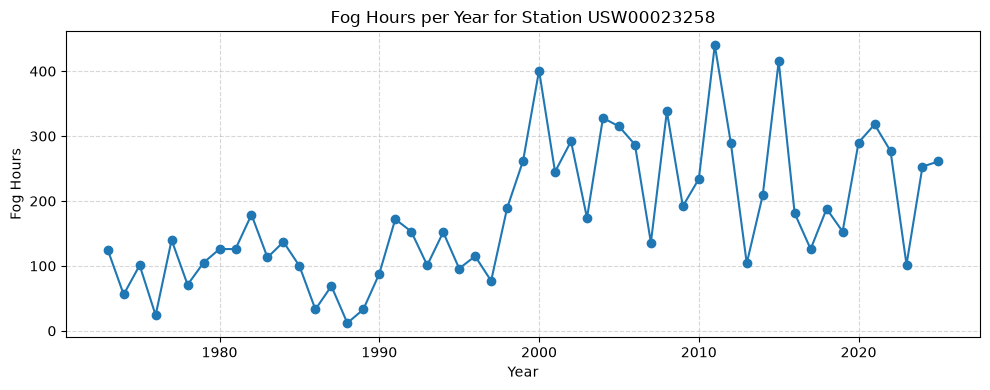

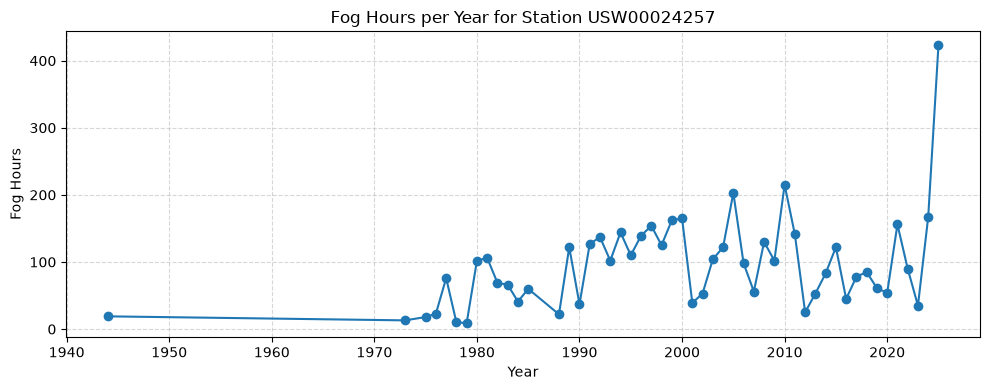

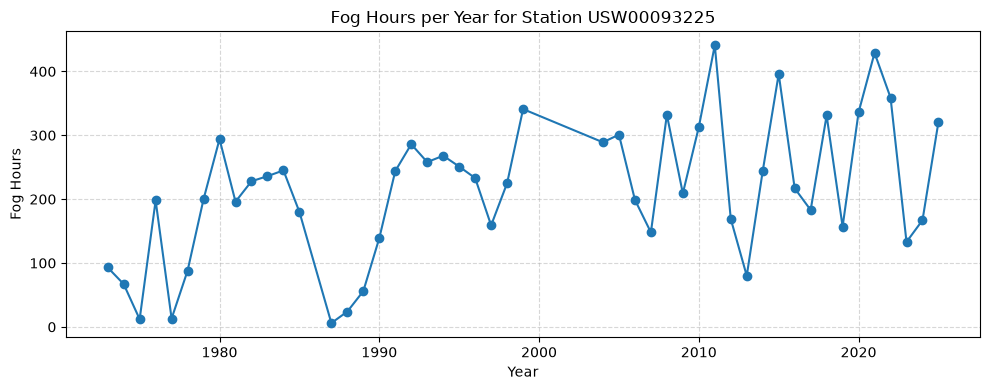

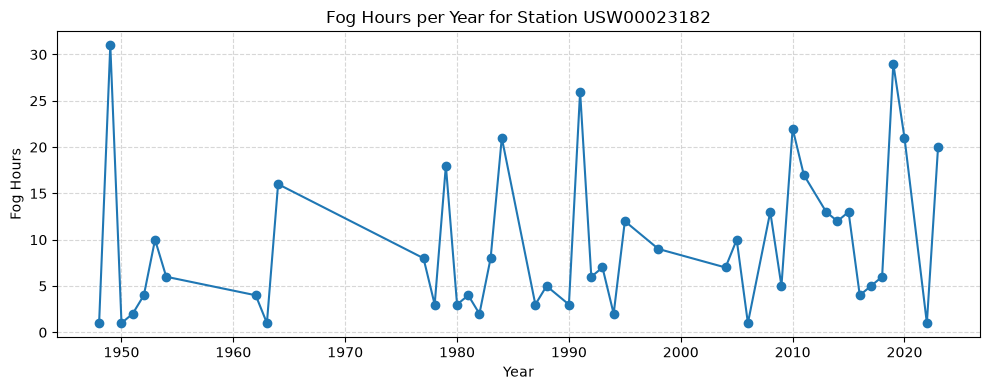

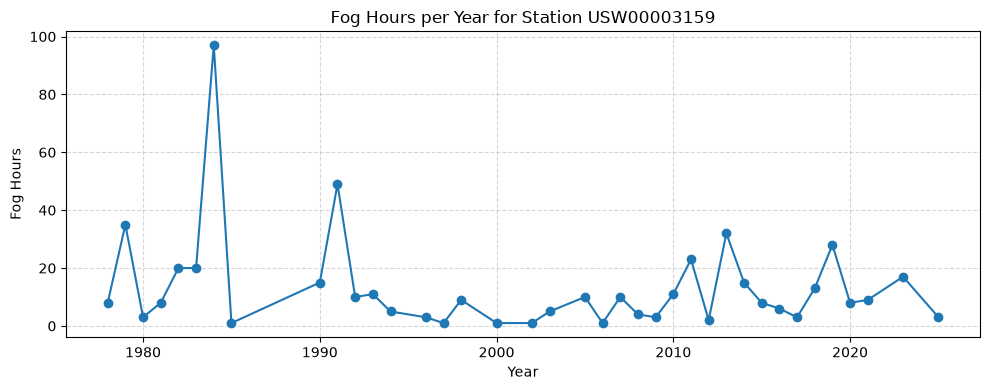

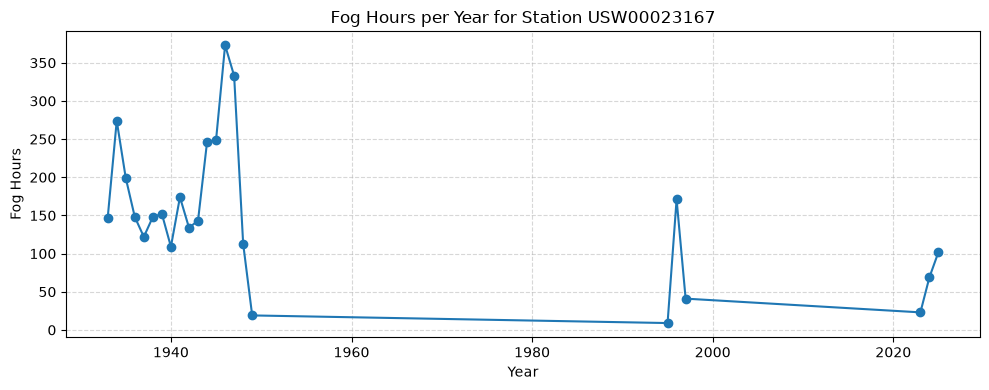

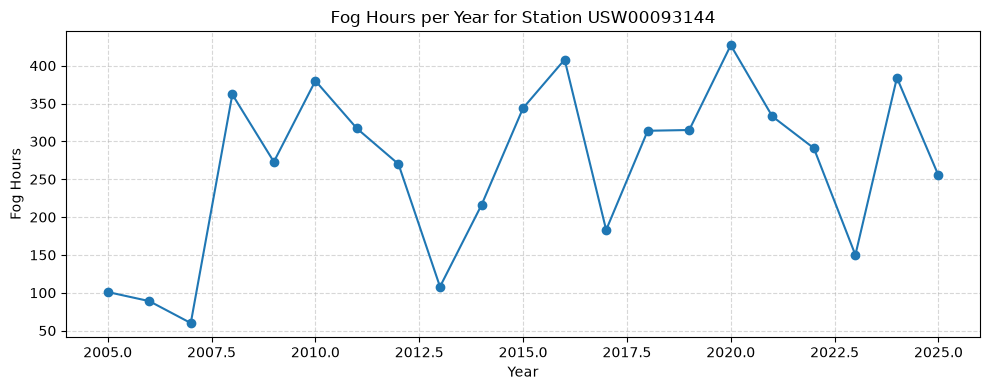

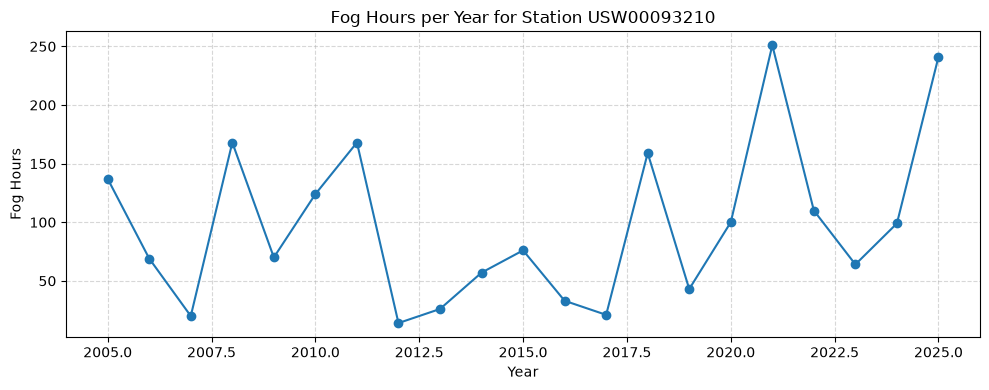

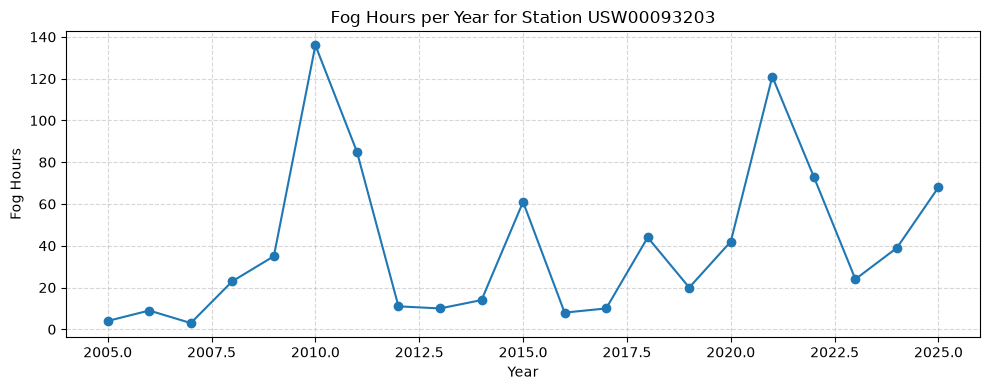

In [20]:
fog_hours_year = (
    CV_fog_rows
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_hours')
)

station_year_counts = fog_hours_year.groupby('STATION')['year'].nunique()
long_term_stations = station_year_counts[station_year_counts > 20].sort_values(ascending=False).index

for station in long_term_stations:
    station_df = fog_hours_year[fog_hours_year['STATION'] == station].sort_values('year')
    plt.figure(figsize=(10, 4))
    plt.plot(station_df['year'], station_df['fog_hours'], marker='o', linestyle='-')
    plt.title(f'Fog Hours per Year for Station {station}')
    plt.xlabel('Year')
    plt.ylabel('Fog Hours')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_14308\4266023836.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


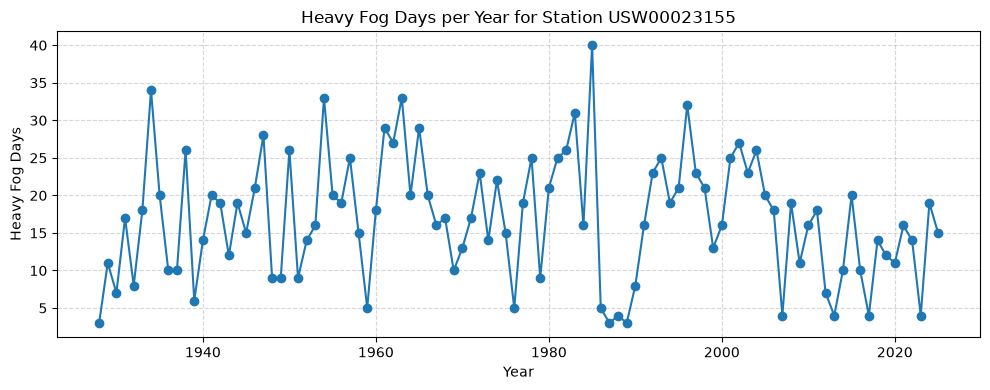

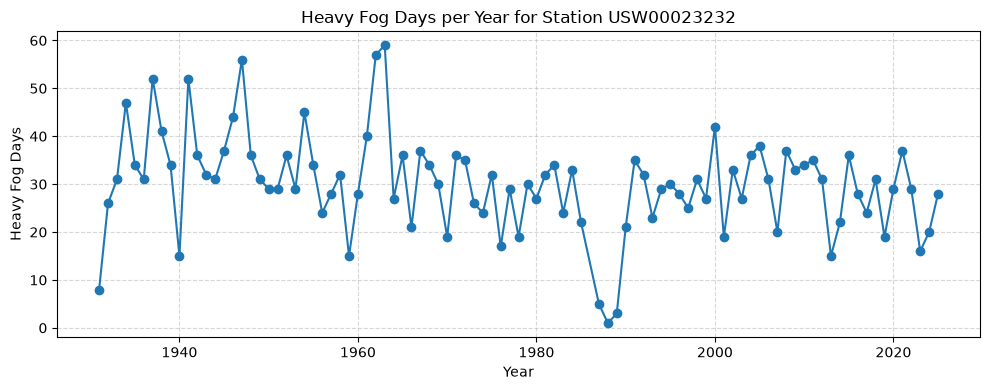

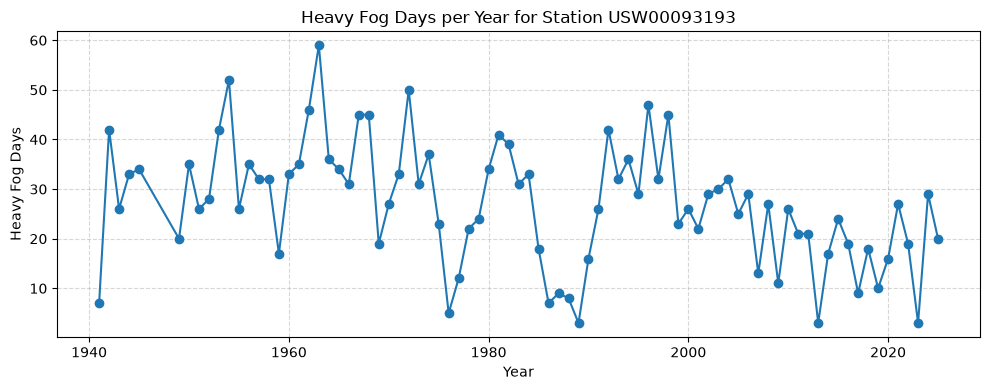

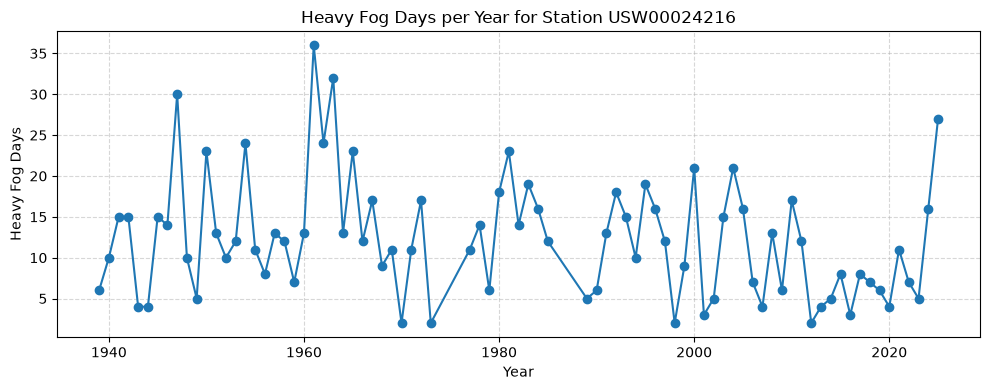

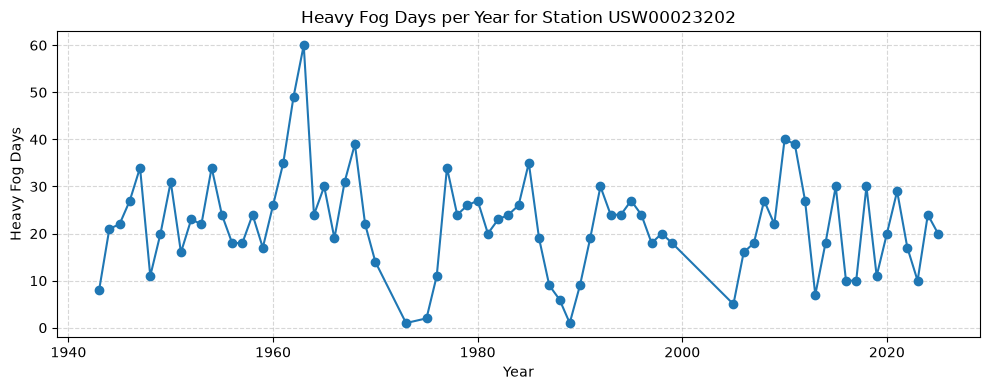

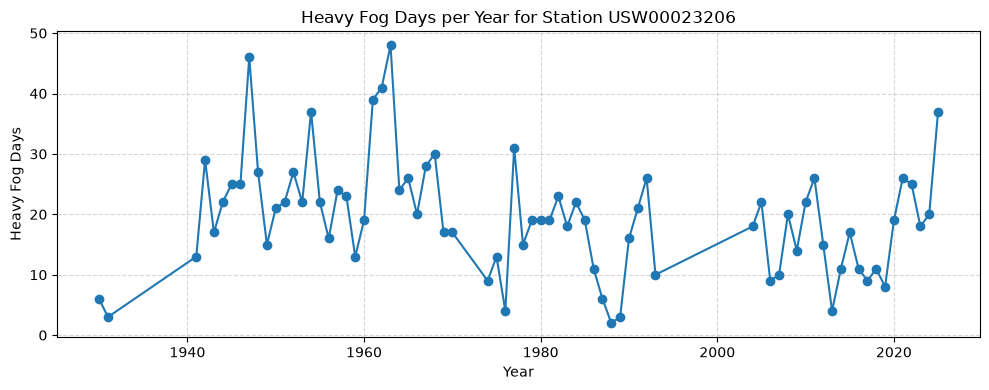

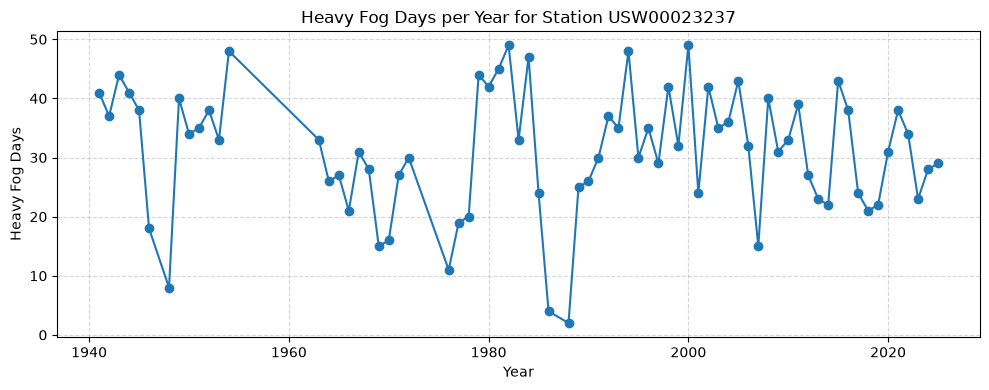

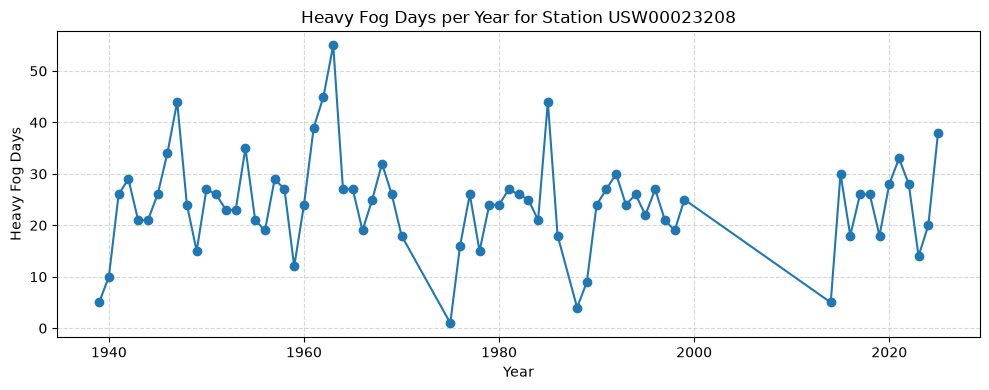

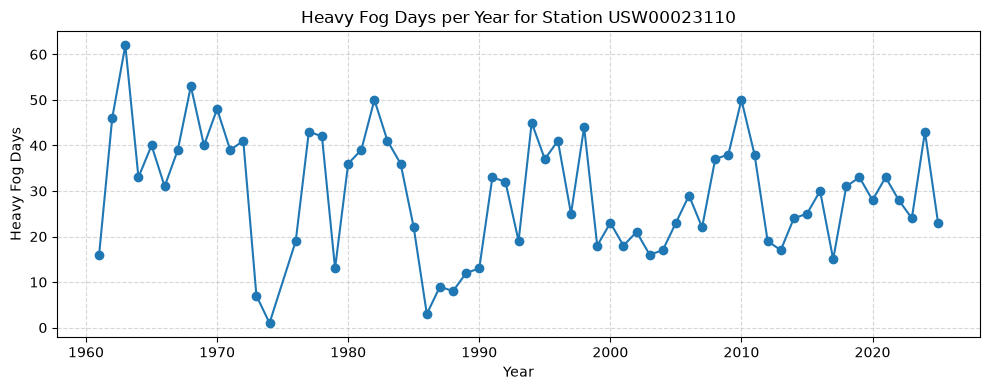

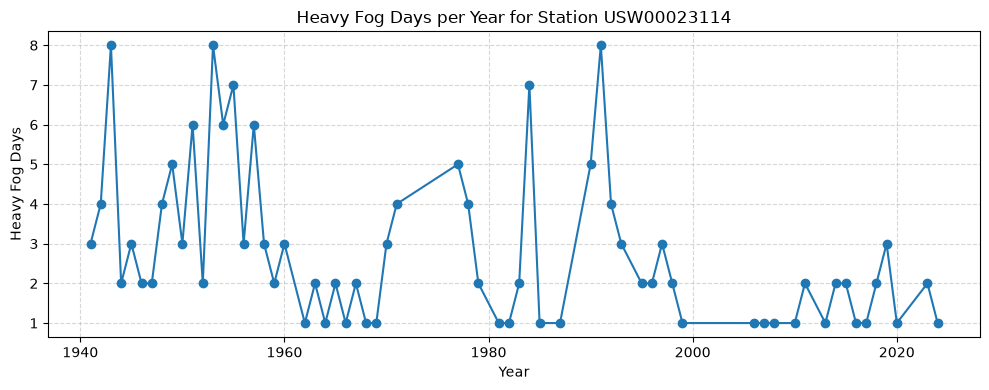

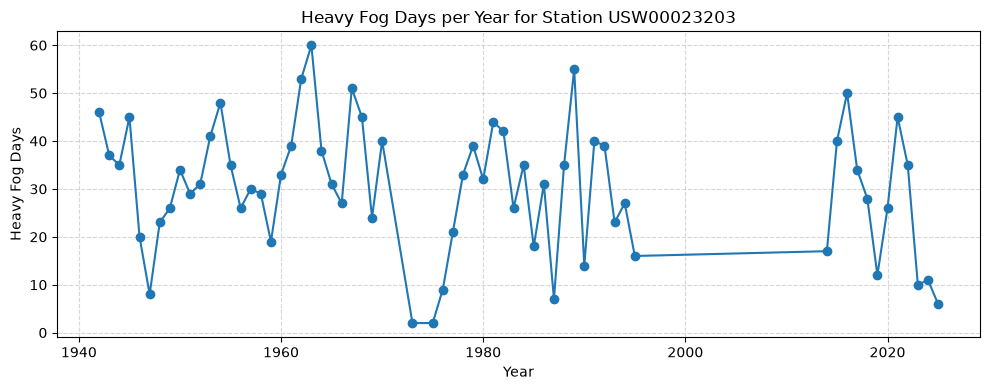

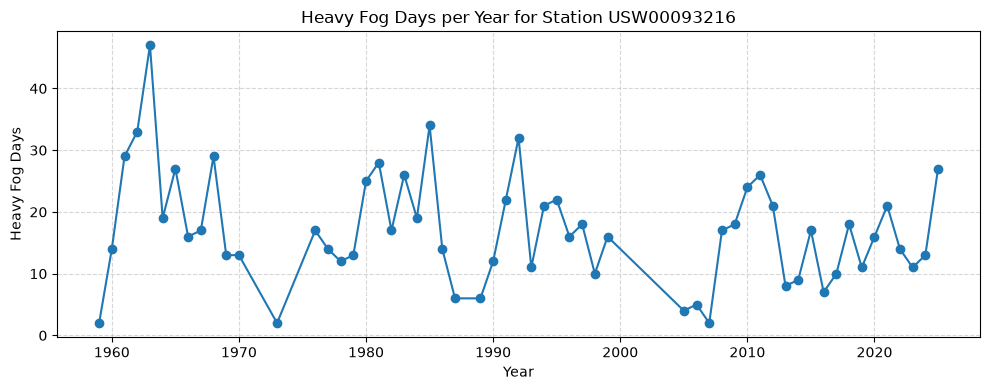

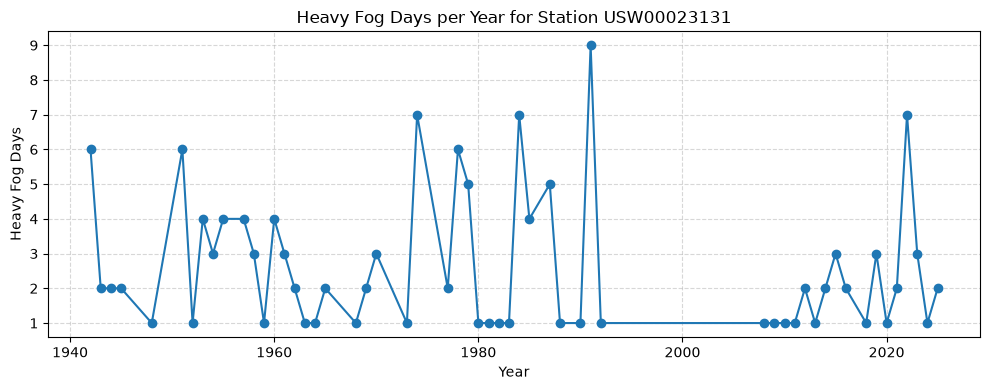

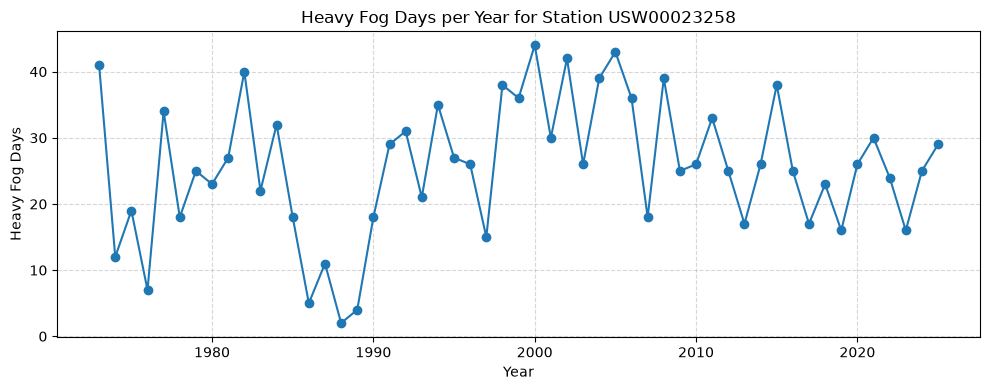

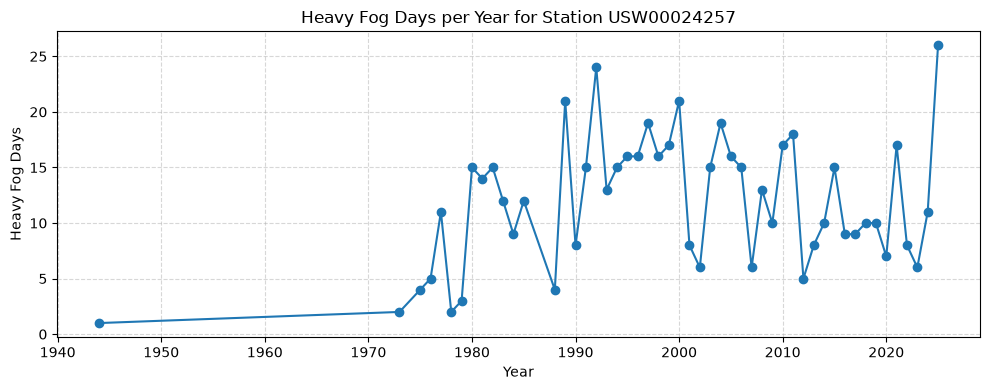

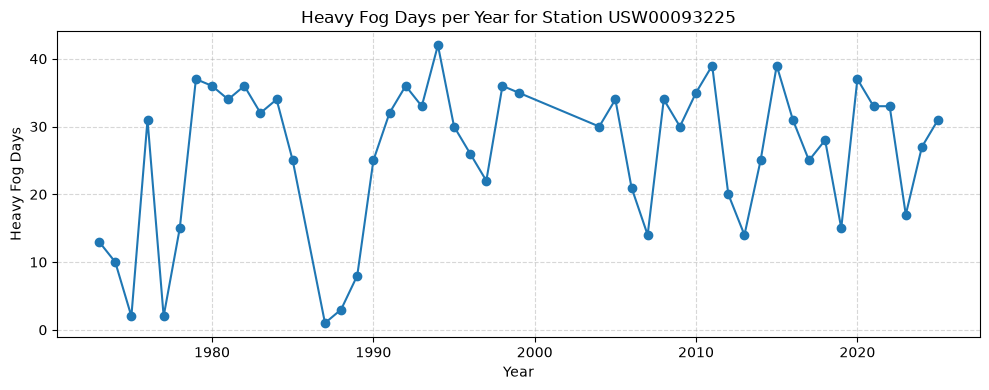

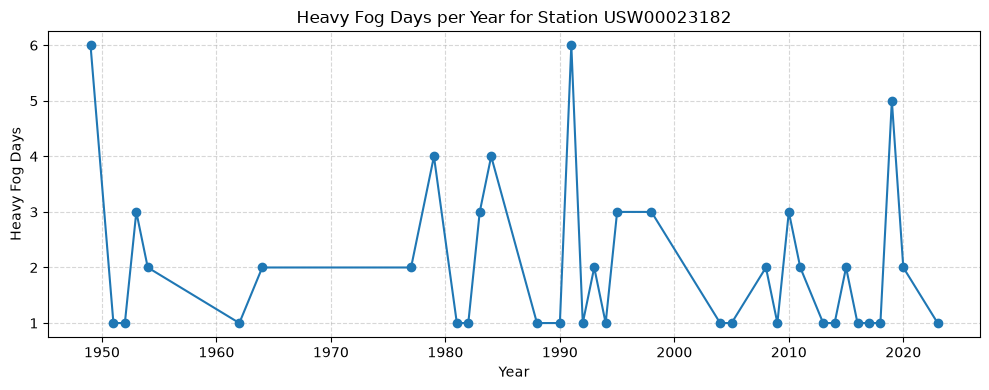

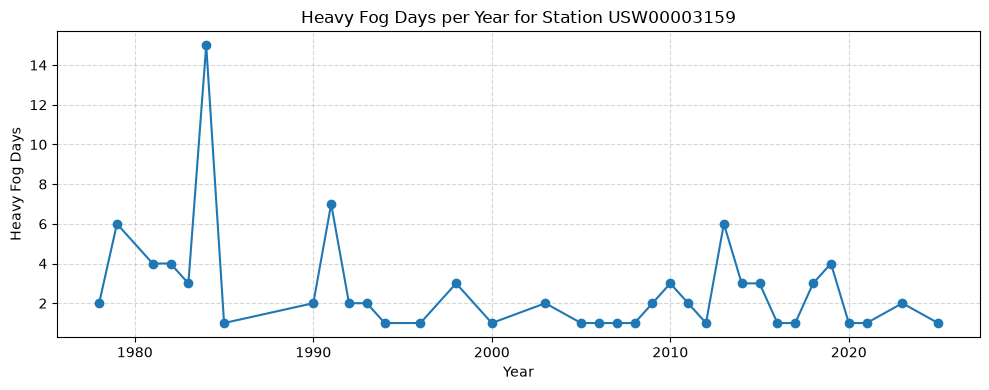

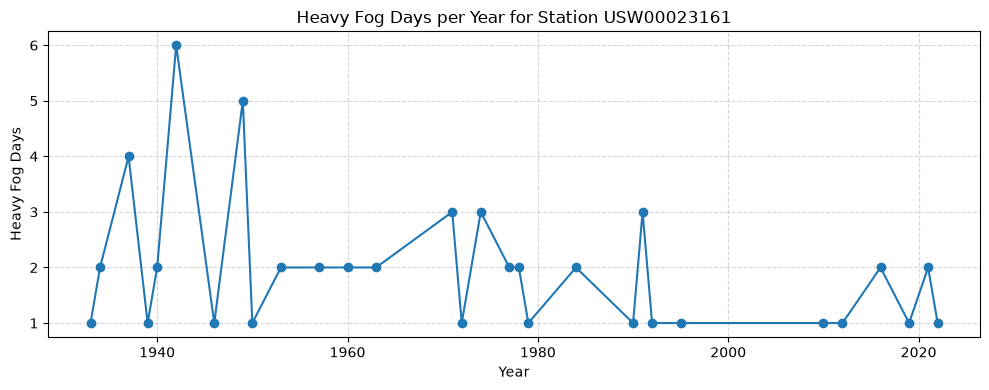

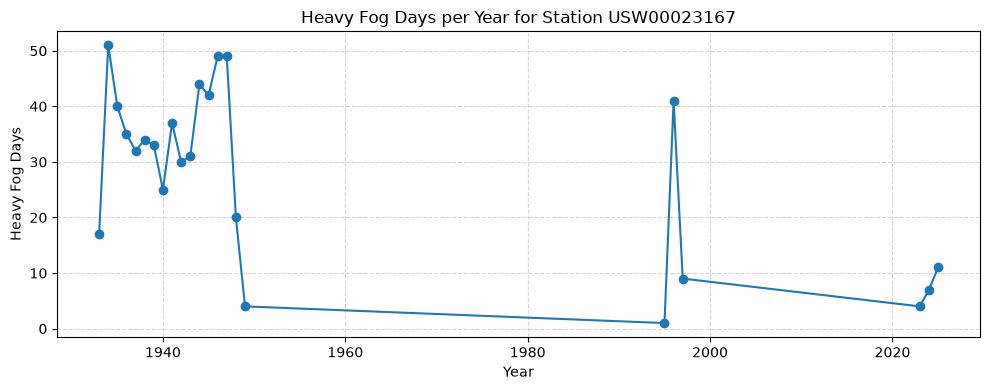

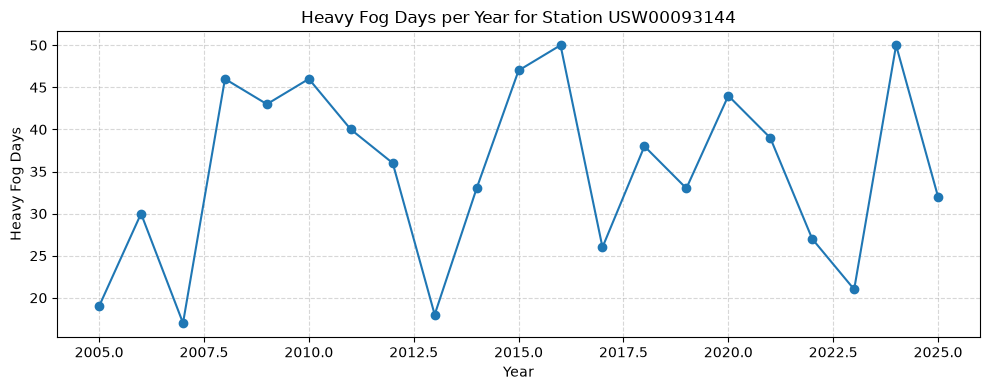

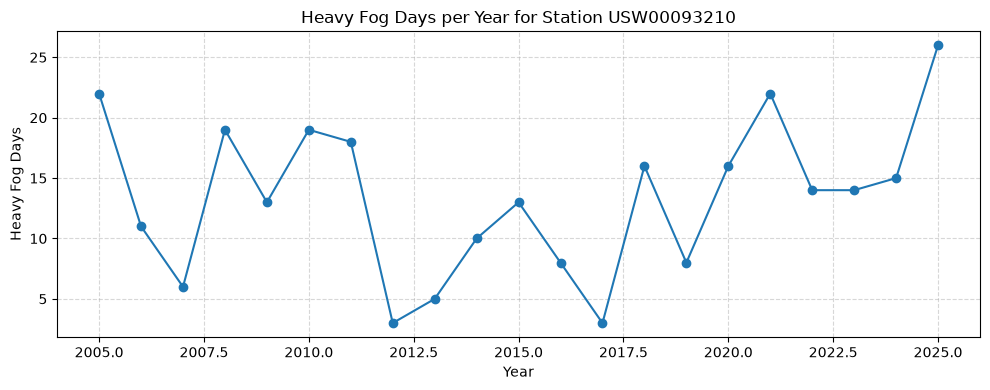

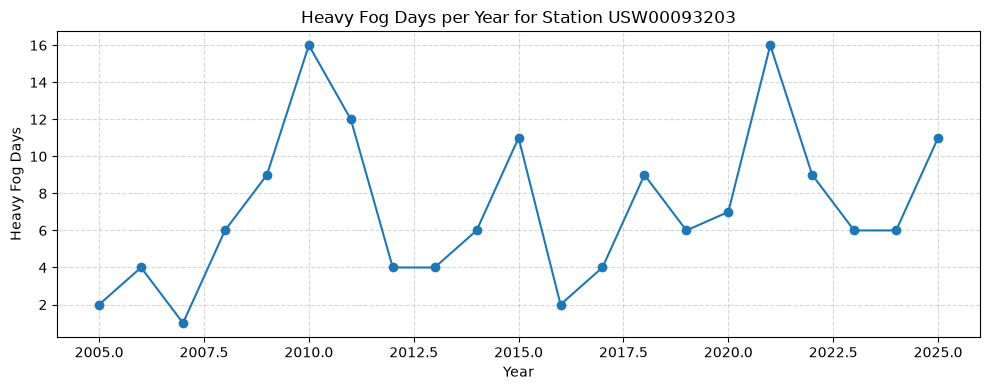

In [21]:
heavy_fog_days_year = (
    CV_densefog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='heavy_fog_days')
)

heavy_station_year_counts = heavy_fog_days_year.groupby('STATION')['year'].nunique()
heavy_long_term_stations = heavy_station_year_counts[heavy_station_year_counts > 20].sort_values(ascending=False).index

for station in heavy_long_term_stations:
    station_df = heavy_fog_days_year[heavy_fog_days_year['STATION'] == station].sort_values('year')
    plt.figure(figsize=(10, 4))
    plt.plot(station_df['year'], station_df['heavy_fog_days'], marker='o', linestyle='-')
    plt.title(f'Heavy Fog Days per Year for Station {station}')
    plt.xlabel('Year')
    plt.ylabel('Heavy Fog Days')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()